# SIMPUL: Diagnosis Friksi Pasar Pangan dan Optimisasi Serapan Permintaan Terjamin di Sulawesi Tenggara

Notebook ini adalah mesin pengolahan untuk naskah opini ilmiah FORKESTRA 2026, subtema
Akselerasi Hilirisasi Sumber Daya Alam, Stabilitas Pangan, dan Sektor Maritim.

Pertanyaan yang dijawab: mengapa provinsi maritim dengan produksi perikanan besar tetap
menghadapi harga pangan yang tinggi dan tidak stabil, sementara nilai produknya justru
keluar sebagai bahan mentah. Jawabannya disusun dalam tiga lapis analisis.

Lapis pertama mendiagnosis friksi. Selisih harga antarwilayah diuraikan menjadi komponen
permanen dan komponen sementara. Komponen permanen mencerminkan biaya logistik struktural,
komponen sementara mencerminkan kegagalan koordinasi. Keduanya memerlukan obat kebijakan
yang berbeda, dan selama ini sering disamakan.

Lapis kedua memetakan struktur. Konektivitas guncangan harga antarkota dan antarkomoditas
diukur dengan dekomposisi varians galat ramalan tergeneralisasi pada vektor autoregresi
berdimensi tinggi.

Lapis ketiga merancang solusi. Alokasi pengadaan bahan pangan program Makan Bergizi Gratis
dirumuskan sebagai masalah pemrograman linear yang memaksimalkan retensi nilai di dalam
provinsi dengan kendala kapasitas pasokan, biaya friksi hasil Lapis pertama, dan batas
toleransi dampak harga.

Seluruh keluaran tabel dan gambar disusun dalam bahasa Inggris agar siap dilampirkan pada
naskah dan publikasi. Penjelasan langkah dan interpretasi disusun dalam bahasa Indonesia.


## Langkah 0. Menyiapkan lingkungan kerja

Sel berikut memasang pustaka yang diperlukan dan memasang berkas huruf serif yang
metriknya setara dengan Times New Roman. Google Colab tidak menyertakan Times New Roman
secara bawaan, sehingga digunakan Liberation Serif yang memiliki lebar karakter identik.
Jika berkas Times New Roman asli tersedia di sistem, berkas itulah yang dipakai.


In [ ]:
import subprocess, sys, os

def pasang(paket):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *paket], check=False)

pasang(["statsmodels>=0.14", "scikit-learn>=1.3", "openpyxl>=3.1", "networkx>=3.0"])

# huruf serif dengan metrik setara Times New Roman
subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-liberation"],
               check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print("Pemasangan pustaka selesai.")

Pemasangan pustaka selesai.


In [ ]:
import os, re, glob, json, zipfile, warnings, unicodedata, datetime as dt
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# ---------------------------------------------------------------
# Konfigurasi huruf: Times New Roman ukuran 13 dengan urutan cadangan
# ---------------------------------------------------------------
font_manager._load_fontmanager(try_read_cache=False)
_tersedia = {f.name for f in font_manager.fontManager.ttflist}
_urutan = ["Times New Roman", "Liberation Serif", "Nimbus Roman", "DejaVu Serif"]
FONT = next((f for f in _urutan if f in _tersedia), "serif")

matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif": [FONT] + _urutan,
    "font.size": 13,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 13,
    "axes.unicode_minus": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.25,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# palet netral yang tetap terbaca bila dicetak hitam putih
WARNA = {
    "struktural": "#1f4e79",
    "koordinasi": "#c0504d",
    "campuran":   "#7f7f7f",
    "aksen":      "#2e7d32",
    "netral":     "#404040",
    "muda":       "#a6bddb",
}

print("Huruf yang dipakai pada visualisasi:", FONT)
print("Ukuran huruf dasar:", matplotlib.rcParams["font.size"])

Huruf yang dipakai pada visualisasi: Liberation Serif
Ukuran huruf dasar: 13.0


## Langkah 1. Membuat struktur folder di Google Drive secara otomatis

Seluruh keluaran disimpan di Google Drive agar tidak hilang ketika sesi Colab berakhir.
Struktur folder dibuat otomatis. Jika notebook dijalankan di luar Colab, folder dibuat di
direktori kerja lokal sehingga kode tetap berjalan tanpa perubahan.


In [ ]:
def siapkan_folder():
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        akar = "/content/drive/MyDrive/SIMPUL_Forkestra2026"
        di_colab = True
    except Exception:
        akar = os.path.abspath("./SIMPUL_Forkestra2026")
        di_colab = False

    sub = ["01_data_mentah", "02_data_bersih", "03_tabel", "04_gambar",
           "05_interpretasi", "06_pustaka"]
    jalur = {"akar": akar}
    for s in sub:
        p = os.path.join(akar, s)
        os.makedirs(p, exist_ok=True)
        jalur[s] = p
    return jalur, di_colab

JALUR, DI_COLAB = siapkan_folder()
print("Berjalan di Google Colab:", DI_COLAB)
print("Folder akar:", JALUR["akar"])
for k, v in JALUR.items():
    if k != "akar":
        print("  -", k, "->", v)

Mounted at /content/drive
Berjalan di Google Colab: True
Folder akar: /content/drive/MyDrive/SIMPUL_Forkestra2026
  - 01_data_mentah -> /content/drive/MyDrive/SIMPUL_Forkestra2026/01_data_mentah
  - 02_data_bersih -> /content/drive/MyDrive/SIMPUL_Forkestra2026/02_data_bersih
  - 03_tabel -> /content/drive/MyDrive/SIMPUL_Forkestra2026/03_tabel
  - 04_gambar -> /content/drive/MyDrive/SIMPUL_Forkestra2026/04_gambar
  - 05_interpretasi -> /content/drive/MyDrive/SIMPUL_Forkestra2026/05_interpretasi
  - 06_pustaka -> /content/drive/MyDrive/SIMPUL_Forkestra2026/06_pustaka


## Langkah 2. Mengunggah berkas data secara otomatis

Sel berikut mencari berkas data pada tiga lokasi secara berurutan. Pertama pada folder
data mentah di Drive, kedua pada direktori kerja Colab, dan ketiga melalui dialog unggah
langsung. Berkas yang berhasil ditemukan disalin ke folder data mentah sehingga
pengolahan berikutnya selalu membaca dari satu tempat yang sama.

Sebelas berkas berikut diperlukan. Nama berkas boleh berbeda selama pola katanya cocok,
karena pencocokan dilakukan dengan pola bukan dengan nama persis.


In [ ]:
import shutil

BERKAS_DIPERLUKAN = {
    "distribusi":     r"Data.?Distribusi.*\.xlsx",
    "produksi":       r"Data.?Produksi.*\.xlsx",
    "sosial":         r"Data.?Sosial.*\.xlsx",
    "nerwilis":       r"Data.?Nerwilis.*\.xlsx",
    "investasi":      r"Dataset.?Investasi.*\.xlsx",
    "nilai_ekspor":   r"1a.*Nilai.?Ekspor.*\.xlsx",
    "nilai_impor":    r"1b.*Nilai.?Impor.*\.xlsx",
    "volume_ekspor":  r"4a.*Volume.?Ekspor.*\.xlsx",
    "volume_impor":   r"4b.*Volume.?Impor.*\.xlsx",
    "parameter":      r"parameter.?terverifikasi.*\.csv",
    "harga_pihps":    r"harga.?pihps.*\.csv",
    "selisih_harga":  r"selisih.?harga.*\.csv",
    "harga_tongkol":  r"harga.?ikan.?tongkol.*\.csv",
}

def cari_berkas(pola, folder_cari):
    for folder in folder_cari:
        if not os.path.isdir(folder):
            continue
        for nama in os.listdir(folder):
            if re.search(pola, nama, flags=re.IGNORECASE):
                return os.path.join(folder, nama)
    return None

def kumpulkan_data():
    folder_cari = [JALUR["01_data_mentah"], "/content", os.getcwd(), "/mnt/project"]
    peta, hilang = {}, []
    for kunci, pola in BERKAS_DIPERLUKAN.items():
        p = cari_berkas(pola, folder_cari)
        if p is None:
            hilang.append(kunci)
        else:
            tujuan = os.path.join(JALUR["01_data_mentah"], os.path.basename(p))
            if os.path.abspath(p) != os.path.abspath(tujuan):
                shutil.copy2(p, tujuan)
            peta[kunci] = tujuan
    return peta, hilang

PETA, HILANG = kumpulkan_data()

if HILANG and DI_COLAB:
    print("Berkas berikut belum ditemukan:", ", ".join(HILANG))
    print("Silakan pilih berkas tersebut pada dialog unggah.")
    from google.colab import files
    diunggah = files.upload()
    for nama in diunggah:
        shutil.move(nama, os.path.join(JALUR["01_data_mentah"], nama))
    PETA, HILANG = kumpulkan_data()

print("Berkas siap pakai:", len(PETA), "dari", len(BERKAS_DIPERLUKAN))
for k, v in sorted(PETA.items()):
    print("  %-15s %s" % (k, os.path.basename(v)))
if HILANG:
    print("\nMasih belum lengkap:", ", ".join(HILANG))
    print("Sebagian analisis akan dilewati secara otomatis.")

Berkas berikut belum ditemukan: distribusi, produksi, sosial, nerwilis, investasi, nilai_ekspor, nilai_impor, volume_ekspor, volume_impor, parameter, harga_pihps, selisih_harga, harga_tongkol
Silakan pilih berkas tersebut pada dialog unggah.


Saving selisih_harga_kendari_baubau.csv to selisih_harga_kendari_baubau.csv
Saving parameter_terverifikasi.csv to parameter_terverifikasi.csv
Saving harga_pihps_kendari_baubau.csv to harga_pihps_kendari_baubau.csv
Saving harga_ikan_tongkol_sultra.csv to harga_ikan_tongkol_sultra.csv
Saving Data Sosial.xlsx to Data Sosial.xlsx
Saving Data Produksi.xlsx to Data Produksi.xlsx
Saving Data Nerwilis.xlsx to Data Nerwilis.xlsx
Saving Data Distribusi.xlsx to Data Distribusi.xlsx
Saving 1a. Nilai Ekspor Provinsi HS 2 Digit 2026Q2_19072026.xlsx to 1a. Nilai Ekspor Provinsi HS 2 Digit 2026Q2_19072026.xlsx
Saving 4b. Volume Impor Provinsi HS 2 Digit 2026Q2_19072026.xlsx to 4b. Volume Impor Provinsi HS 2 Digit 2026Q2_19072026.xlsx
Saving 1b. Nilai Impor Provinsi HS 2 Digit 2026Q2_19072026.xlsx to 1b. Nilai Impor Provinsi HS 2 Digit 2026Q2_19072026.xlsx
Saving 4a. Volume Ekspor Provinsi HS 2 Digit 2026Q2_19072026.xlsx to 4a. Volume Ekspor Provinsi HS 2 Digit 2026Q2_19072026.xlsx
Saving Dataset Inves

## Langkah 3. Pembersihan dan integrasi data

Berkas yang bersumber dari Badan Pusat Statistik tersusun untuk dibaca manusia, bukan untuk
diolah mesin. Judul tabel diletakkan di beberapa baris pertama, kepala kolom bertingkat dua
atau tiga baris, sel digabung, dan satu lembar kerja sering memuat lebih dari satu tabel.
Karena itu setiap sumber memerlukan penerjemah sendiri.

Prinsip yang dipakai adalah mengubah semua sumber menjadi bentuk panjang dengan kolom
identitas yang seragam, yaitu wilayah, waktu, variabel, dan nilai. Bentuk ini memungkinkan
seluruh sumber digabung tanpa kehilangan informasi dan tanpa asumsi tambahan.

Nilai yang ditulis sebagai tanda hubung diperlakukan sebagai data tidak tersedia, bukan
sebagai nol. Perbedaan ini penting karena nol berarti tidak ada produksi sedangkan tanda
hubung berarti tidak dilaporkan.


In [ ]:
BULAN = {"Jan":1,"Feb":2,"Mar":3,"Apr":4,"Mei":5,"Jun":6,"Jul":7,"Agu":8,"Sep":9,
         "Okt":10,"Nov":11,"Des":12,"Januari":1,"Februari":2,"Maret":3,"April":4,
         "Juni":6,"Juli":7,"Agustus":8,"September":9,"Oktober":10,"November":11,
         "Desember":12}

def rapikan(x):
    """Menormalkan teks sel: menghapus spasi ganda dan karakter tak kasat mata."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    s = unicodedata.normalize("NFKD", str(x)).replace("\xa0", " ").strip()
    return re.sub(r"\s+", " ", s)

def ke_angka(x):
    """Mengubah sel menjadi angka. Tanda hubung dan sel kosong menjadi data hilang."""
    s = rapikan(x)
    if s is None or s in {"-", "--", "", "...", "n.a.", "NA"}:
        return np.nan
    s = s.replace(" ", "").replace("%", "")
    if re.fullmatch(r"-?\d{1,3}(\.\d{3})+,\d+", s):      # format Indonesia
        s = s.replace(".", "").replace(",", ".")
    elif re.fullmatch(r"-?\d+,\d+", s):
        s = s.replace(",", ".")
    else:
        s = s.replace(",", "")
    try:
        return float(s)
    except ValueError:
        return np.nan

# Tujuh belas kabupaten dan kota di Sulawesi Tenggara. Daftar ini dipakai sebagai
# penyaring baku sehingga baris keterangan, baris jumlah, dan catatan kaki yang ikut
# terbaca dari lembar kerja tidak masuk ke dalam tabel hasil.
WILAYAH_SULTRA = ["Buton", "Muna", "Konawe", "Kolaka", "Konawe Selatan", "Bombana",
                  "Wakatobi", "Kolaka Utara", "Buton Utara", "Konawe Utara",
                  "Kolaka Timur", "Konawe Kepulauan", "Muna Barat", "Buton Tengah",
                  "Buton Selatan", "Kendari", "Baubau"]

# Gugus geografis. Kabupaten kepulauan hanya terhubung ke daratan melalui angkutan laut,
# sehingga biaya perpindahan barang antargugus berbeda dari biaya di dalam satu gugus.
GUGUS = {"Buton": "kepulauan", "Muna": "kepulauan", "Wakatobi": "kepulauan",
         "Buton Utara": "kepulauan", "Konawe Kepulauan": "kepulauan",
         "Muna Barat": "kepulauan", "Buton Tengah": "kepulauan",
         "Buton Selatan": "kepulauan", "Baubau": "kepulauan",
         "Konawe": "daratan", "Kolaka": "daratan", "Konawe Selatan": "daratan",
         "Bombana": "daratan", "Kolaka Utara": "daratan", "Konawe Utara": "daratan",
         "Kolaka Timur": "daratan", "Kendari": "daratan"}

def samakan_wilayah(s):
    """Menyeragamkan penulisan nama kabupaten dan kota."""
    s = rapikan(s) or ""
    s = re.sub(r"^(Kota|Kabupaten|Kab\.?)\s+", "", s, flags=re.IGNORECASE)
    s = s.replace("Bau-bau", "Baubau").replace("Bau Bau", "Baubau")
    s = s.replace("Konawe Kep.", "Konawe Kepulauan")
    return s.strip().title()

def hanya_sultra(d, kolom="wilayah"):
    """Menyaring tabel agar hanya memuat tujuh belas wilayah resmi."""
    return d[d[kolom].isin(WILAYAH_SULTRA)].copy()

# ---------------------------------------------------------------
# Penerjemah 1: indeks harga konsumen menurut kelompok pengeluaran
# ---------------------------------------------------------------
def baca_ihk(berkas, lembar, wilayah):
    d = pd.read_excel(berkas, sheet_name=lembar, header=None)
    tahun, bulan = d.iloc[0].ffill(), d.iloc[1]
    kolom = []
    for j in range(2, d.shape[1]):
        t, b = tahun.iloc[j], bulan.iloc[j]
        if pd.isna(t) or pd.isna(b):
            continue
        try:
            t = int(float(t))
        except (TypeError, ValueError):
            continue
        m = BULAN.get(rapikan(b))
        if m:
            kolom.append((j, pd.Timestamp(t, m, 1)))
    baris = []
    for i in range(2, len(d)):
        kode, nama = rapikan(d.iat[i, 0]), rapikan(d.iat[i, 1])
        if not kode or not nama:
            continue
        kode = kode.replace(".0", "")
        for j, tgl in kolom:
            v = ke_angka(d.iat[i, j])
            if not np.isnan(v):
                baris.append((wilayah, kode, nama, tgl, v))
    return pd.DataFrame(baris, columns=["wilayah", "kode", "kelompok", "tanggal", "ihk"])

# ---------------------------------------------------------------
# Penerjemah 2: perdagangan luar negeri menurut kode HS dua digit
# ---------------------------------------------------------------
def baca_perdagangan(berkas, lembar, nama_nilai):
    d = pd.read_excel(berkas, sheet_name=lembar, header=5)
    d = d[pd.to_numeric(d["HS "], errors="coerce").notna()].copy()
    d["hs"] = d["HS "].astype(float).astype(int)
    kolom = [c for c in d.columns if isinstance(c, dt.datetime)]
    panjang = d.melt(id_vars=["hs", "KELOMPOK KOMODITI"], value_vars=kolom,
                     var_name="tanggal", value_name=nama_nilai)
    panjang["tanggal"] = pd.to_datetime(panjang["tanggal"])
    panjang[nama_nilai] = pd.to_numeric(panjang[nama_nilai], errors="coerce")
    return panjang.rename(columns={"KELOMPOK KOMODITI": "komoditi"})

def baca_kurs(berkas):
    """Kurs rata-rata bulanan yang dipakai BPS untuk mengonversi nilai perdagangan."""
    d = pd.read_excel(berkas, sheet_name="Data Dasar SM (US$)", header=5)
    kolom = [c for c in d.columns if isinstance(c, dt.datetime)]
    baris = d[d.iloc[:, 2].astype(str).str.strip().eq("Kurs")]
    s = pd.to_numeric(baris[kolom].iloc[0], errors="coerce")
    s.index = pd.to_datetime(kolom)
    return s.dropna().rename("kurs")

# ---------------------------------------------------------------
# Penerjemah 3: nilai tukar petani menurut subsektor
# ---------------------------------------------------------------
def baca_ntp(berkas):
    d = pd.read_excel(berkas, sheet_name="NTP", header=None)
    tahun, bulan = d.iloc[1].ffill(), d.iloc[2]
    kolom = []
    for j in range(1, d.shape[1]):
        t, b = tahun.iloc[j], bulan.iloc[j]
        if pd.isna(t) or pd.isna(b):
            continue
        cocok = re.findall(r"(\d{4})", str(t))
        m = BULAN.get(rapikan(b))
        if cocok and m:
            kolom.append((j, pd.Timestamp(int(cocok[0]), m, 1)))
    subsektor = {"Tanaman Pangan", "Hortikultura", "Perkebunan Rakyat",
                 "Peternakan", "Perikanan", "NTP Gabungan"}
    blok, baris = None, []
    for i in range(len(d)):
        lab = rapikan(d.iat[i, 0]) or ""
        if lab.lower().startswith(("nilai tukar", "indeks")):
            blok = lab
            continue
        if lab in subsektor:
            for j, tgl in kolom:
                v = ke_angka(d.iat[i, j])
                if not np.isnan(v):
                    baris.append((blok, lab, tgl, v))
    return pd.DataFrame(baris, columns=["indikator", "subsektor", "tanggal", "nilai"])

# ---------------------------------------------------------------
# Penerjemah 4: produksi perikanan tangkap laut menurut kabupaten
# ---------------------------------------------------------------
def baca_perikanan(berkas):
    d = pd.read_excel(berkas, sheet_name="Perikanan", header=None)
    awal = None
    for i in range(len(d)):
        v = rapikan(d.iat[i, 0]) or ""
        if "PERIKANAN TANGKAP DI PERAIRAN LAUT" in v.upper():
            awal = i
            break
    if awal is None:
        return pd.DataFrame()
    kepala = awal + 3
    tahun = [(j, int(float(d.iat[kepala, j])))
             for j in range(2, d.shape[1])
             if pd.notna(d.iat[kepala, j]) and str(d.iat[kepala, j]).replace(".0", "").isdigit()]
    baris = []
    for i in range(kepala + 2, min(kepala + 22, len(d))):
        nama = rapikan(d.iat[i, 1])
        if not nama or nama.lower().startswith("jumlah"):
            continue
        for j, t in tahun:
            rtp = ke_angka(d.iat[i, j])
            prod = ke_angka(d.iat[i, j + 1])
            baris.append((samakan_wilayah(nama), t, rtp, prod))
    return hanya_sultra(pd.DataFrame(baris, columns=["wilayah", "tahun", "rtp", "produksi_ton"]))

# ---------------------------------------------------------------
# Penerjemah 5: proyeksi penduduk menurut kabupaten
# ---------------------------------------------------------------
def baca_penduduk(berkas, tahun_target=2026):
    d = pd.read_excel(berkas, sheet_name="Penduduk", header=None)
    awal = None
    for i in range(len(d)):
        v = rapikan(d.iat[i, 0]) or ""
        if "Hasil Proyeksi SP2020" in v:
            awal = i
            break
    if awal is None:
        return pd.DataFrame()
    b_tahun, b_jk = awal + 3, awal + 4
    tahun = d.iloc[b_tahun].ffill()
    kolom = [j for j in range(1, d.shape[1])
             if str(tahun.iloc[j]).replace(".0", "") == str(tahun_target)
             and str(d.iat[b_jk, j]).startswith("Perempuan+")]
    if not kolom:
        return pd.DataFrame()
    baris = []
    for i in range(b_jk + 1, min(b_jk + 20, len(d))):
        nama = rapikan(d.iat[i, 0])
        if not nama or nama.lower().startswith(("sulawesi", "jumlah")):
            continue
        v = ke_angka(d.iat[i, kolom[0]])
        if not np.isnan(v):
            baris.append((samakan_wilayah(nama), v * 1000.0))
    return hanya_sultra(pd.DataFrame(baris, columns=["wilayah", "penduduk"]))

print("Fungsi penerjemah data siap.")

Fungsi penerjemah data siap.


### Menjalankan pembersihan dan memeriksa kualitas hasil

Setiap sumber dibaca, lalu diperiksa cakupan waktu, jumlah wilayah, dan proporsi data
hilang. Pemeriksaan ini penting karena kesalahan pembacaan pada berkas bertingkat sering
tidak menimbulkan pesan kesalahan, melainkan menghasilkan tabel yang tampak wajar tetapi
isinya bergeser.


In [ ]:
DATA = {}

# indeks harga konsumen empat wilayah
lembar_ihk = [("IHK Kota Kendari 2022=100", "Kendari"),
              ("IHK Kota Baubau 2022=100", "Baubau"),
              ("IHK Kab Konawe 2022=100", "Konawe"),
              ("IHK Kab Kolaka 2022=100", "Kolaka")]
DATA["ihk"] = pd.concat([baca_ihk(PETA["distribusi"], s, w) for s, w in lembar_ihk],
                        ignore_index=True)

# perdagangan luar negeri dan kurs
nilai_ekspor  = baca_perdagangan(PETA["nilai_ekspor"],  "Data Dasar SM (US$)", "usd")
volume_ekspor = baca_perdagangan(PETA["volume_ekspor"], "Volume SM (KG)",      "kg")
DATA["ekspor"] = nilai_ekspor.merge(volume_ekspor[["hs", "tanggal", "kg"]],
                                    on=["hs", "tanggal"], how="left")
DATA["kurs"] = baca_kurs(PETA["nilai_ekspor"])

# nilai tukar petani, perikanan, penduduk
DATA["ntp"]        = baca_ntp(PETA["distribusi"])
DATA["perikanan"]  = baca_perikanan(PETA["produksi"])
DATA["penduduk"]   = baca_penduduk(PETA["sosial"], 2026)

# berkas harga yang sudah berbentuk rapi
DATA["selisih"]  = pd.read_csv(PETA["selisih_harga"], parse_dates=["tanggal"])
DATA["pihps"]    = pd.read_csv(PETA["harga_pihps"],   parse_dates=["tanggal"])
DATA["tongkol"]  = pd.read_csv(PETA["harga_tongkol"], parse_dates=["tanggal"])
DATA["parameter"] = pd.read_csv(PETA["parameter"])

def periksa(nama, d):
    if not isinstance(d, pd.DataFrame) or d.empty:
        return dict(sumber=nama, baris=0, catatan="kosong")
    hilang = float(d.isna().mean().mean() * 100)
    ket = []
    if "tanggal" in d.columns:
        ket.append("%s sampai %s" % (d.tanggal.min().date(), d.tanggal.max().date()))
    if "wilayah" in d.columns:
        ket.append("%d wilayah" % d.wilayah.nunique())
    if "tahun" in d.columns:
        ket.append("tahun %d sampai %d" % (d.tahun.min(), d.tahun.max()))
    return dict(sumber=nama, baris=len(d), kolom=d.shape[1],
                persen_hilang=round(hilang, 2), catatan="; ".join(ket))

LAPORAN_MUTU = pd.DataFrame([periksa(k, v) for k, v in DATA.items()
                             if isinstance(v, pd.DataFrame)])
print(LAPORAN_MUTU.to_string(index=False))
print()
print("Kurs bulanan: %s sampai %s, %d titik, rata-rata 2026 sebesar Rp%s"
      % (DATA["kurs"].index.min().date(), DATA["kurs"].index.max().date(),
         len(DATA["kurs"]),
         format(DATA["kurs"][DATA["kurs"].index.year == 2026].mean(), ",.0f")))

for nama, d in DATA.items():
    if isinstance(d, pd.DataFrame) and not d.empty:
        d.to_csv(os.path.join(JALUR["02_data_bersih"], "bersih_%s.csv" % nama), index=False)
DATA["kurs"].to_frame().to_csv(os.path.join(JALUR["02_data_bersih"], "bersih_kurs.csv"))
print("\nSeluruh tabel bersih disimpan di folder 02_data_bersih.")

   sumber  baris  kolom  persen_hilang                                 catatan
      ihk   5921      5           0.00 2024-01-01 sampai 2026-07-01; 4 wilayah
   ekspor  15444      5           9.54            2014-01-01 sampai 2026-12-01
      ntp   4488      4           0.00            2010-01-01 sampai 2026-07-01
perikanan    102      4           8.82      17 wilayah; tahun 2013 sampai 2018
 penduduk     17      2           0.00                              17 wilayah
  selisih    720      6           0.00            2020-02-03 sampai 2026-08-03
    pihps   4880      6           1.67            2020-01-01 sampai 2026-08-03
  tongkol     36      5           0.00 2022-01-01 sampai 2024-12-01; 1 wilayah
parameter     18      4           0.00                                        

Kurs bulanan: 2014-01-01 sampai 2026-06-01, 150 titik, rata-rata 2026 sebesar Rp17,110

Seluruh tabel bersih disimpan di folder 02_data_bersih.


## Langkah 4. Lapis pertama, mendiagnosis dua jenis friksi pasar

Selisih harga sebuah komoditas antara dua kota dapat lahir dari dua sebab yang berbeda
secara mendasar. Sebab pertama adalah biaya memindahkan barang, yang bersifat menetap
karena berasal dari jarak, moda angkutan, dan susut perjalanan. Sebab kedua adalah
ketidaktahuan pelaku pasar mengenai harga di tempat lain, yang bersifat sementara karena
akan hilang begitu informasi tersebar.

Membedakan keduanya penting karena obatnya berlawanan. Selisih yang menetap hanya bisa
ditekan dengan perbaikan sarana angkutan dan penjadwalan pelayaran. Selisih yang berubah
ubah tidak akan berkurang meskipun jalan diperlebar, karena masalahnya bukan pada
perpindahan barang melainkan pada perpindahan informasi.

Model komponen tak teramati dipakai untuk memisahkan keduanya. Selisih logaritma harga
antara dua kota dituliskan sebagai penjumlahan sebuah taraf yang berjalan acak dan sebuah
gangguan sesaat.

$$q_t = \mu_t + \varepsilon_t, \qquad \varepsilon_t \sim N(0, \sigma^2_{\varepsilon})$$

$$\mu_t = \mu_{t-1} + \eta_t, \qquad \eta_t \sim N(0, \sigma^2_{\eta})$$

dengan $q_t = \ln P^{Kendari}_t - \ln P^{Baubau}_t$. Suku $\mu_t$ menyerap friksi struktural
karena guncangan terhadapnya tidak pernah hilang, sedangkan $\varepsilon_t$ menyerap
gangguan yang lenyap pada periode berikutnya.

Ukuran yang dipakai untuk menggolongkan komoditas adalah pangsa ragam permanen.

$$\pi = \frac{\sigma^2_{\eta}}{\sigma^2_{\eta} + \sigma^2_{\varepsilon}}$$

Nilai $\pi$ mendekati satu berarti hampir seluruh selisih bersifat menetap, sehingga
persoalannya adalah logistik. Nilai $\pi$ mendekati nol berarti hampir seluruh selisih
bersifat sesaat, sehingga persoalannya adalah koordinasi. Kedua ragam diduga dengan
kemungkinan maksimum melalui saringan Kalman mengikuti Harvey (1989) dan Durbin dan
Koopman (2012).

Sebagai pemeriksaan silang, dilakukan pula uji akar unit Dickey dan Fuller yang diperluas
serta uji Kwiatkowski dan rekan. Kedua uji ini menjawab pertanyaan yang sama dari arah
yang berlawanan, sehingga kesimpulan yang sejalan memperkuat keyakinan pada hasil.


In [ ]:
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.stattools import adfuller, kpss

def uraikan_selisih(q):
    """Memisahkan komponen permanen dan sementara dari deret selisih harga."""
    q = np.asarray(pd.Series(q).dropna(), dtype=float)
    model = UnobservedComponents(q, level="local level").fit(disp=False)
    par = dict(zip(model.param_names, model.params))
    s2_eps = max(float(par["sigma2.irregular"]), 0.0)
    s2_eta = max(float(par["sigma2.level"]), 0.0)
    total = s2_eps + s2_eta
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        p_adf = adfuller(q, autolag="AIC")[1]
        p_kpss = kpss(q, regression="c", nlags="auto")[1]
    return dict(
        n=len(q),
        sd_permanen_pp=np.sqrt(s2_eta) * 100,
        sd_sementara_pp=np.sqrt(s2_eps) * 100,
        pangsa_permanen=s2_eta / total if total > 0 else np.nan,
        selisih_rerata_pct=(np.exp(q.mean()) - 1) * 100,
        p_adf=p_adf, p_kpss=p_kpss, loglik=model.llf,
        taraf=model.smoothed_state[0] if model.smoothed_state.size else None,
    )

def golongkan(pi):
    if np.isnan(pi):
        return "Undetermined"
    if pi >= 0.50:
        return "Structural friction"
    if pi <= 0.20:
        return "Coordination failure"
    return "Mixed"

hasil = {}
for komoditas, sub in DATA["selisih"].sort_values("tanggal").groupby("komoditas"):
    hasil[komoditas] = uraikan_selisih(sub["selisih_log"].values)

LAPIS1 = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "taraf"}
                       for k, v in hasil.items()}).T
LAPIS1["golongan"] = LAPIS1["pangsa_permanen"].map(golongkan)
LAPIS1 = LAPIS1.sort_values("pangsa_permanen", ascending=False)

TABEL1 = LAPIS1.rename(columns={
    "n": "Obs.", "sd_permanen_pp": "SD permanent (pp)",
    "sd_sementara_pp": "SD transitory (pp)", "pangsa_permanen": "Permanent share",
    "selisih_rerata_pct": "Mean wedge (%)", "p_adf": "ADF p-value",
    "p_kpss": "KPSS p-value", "golongan": "Classification"})
TABEL1.index.name = "Commodity"
TABEL1 = TABEL1[["Obs.", "Mean wedge (%)", "SD permanent (pp)", "SD transitory (pp)",
                 "Permanent share", "ADF p-value", "KPSS p-value", "Classification"]]
print(TABEL1.round(4).to_string())
TABEL1.round(4).to_csv(os.path.join(JALUR["03_tabel"],
                       "table1_friction_taxonomy.csv"))

               Obs.  Mean wedge (%)  SD permanent (pp)  SD transitory (pp)  Permanent share  ADF p-value  KPSS p-value        Classification
Commodity                                                                                                                                   
Gula Pasir     72.0         -6.3474             2.0407              0.0005           1.0000       0.3921        0.0214   Structural friction
Beras          72.0          6.1292             1.7304              0.0005           1.0000       0.0709        0.1000   Structural friction
Daging Sapi    72.0         -3.4612             1.6406              0.9990           0.7295       0.0653        0.0100   Structural friction
Minyak Goreng  72.0        -11.8376             1.7999              1.7218           0.5222       0.3364        0.1000   Structural friction
Bawang Putih   72.0          4.5125             4.3509              4.8217           0.4488       0.0002        0.1000                 Mixed
Cabai Rawit  

### Gambar pertama, peta taksonomi friksi

Setiap komoditas ditempatkan menurut besar selisih harga rata rata pada sumbu mendatar dan
pangsa ragam permanen pada sumbu tegak. Pembacaannya sederhana. Titik yang berada di atas
menandakan persoalan logistik, titik yang berada di bawah menandakan persoalan koordinasi.
Titik yang berada jauh di kiri atau kanan menandakan selisih harga yang besar.

Kuadran kanan atas dan kiri atas adalah wilayah yang menuntut penanganan angkutan.
Kuadran bawah adalah wilayah yang menuntut penanganan informasi pasar.


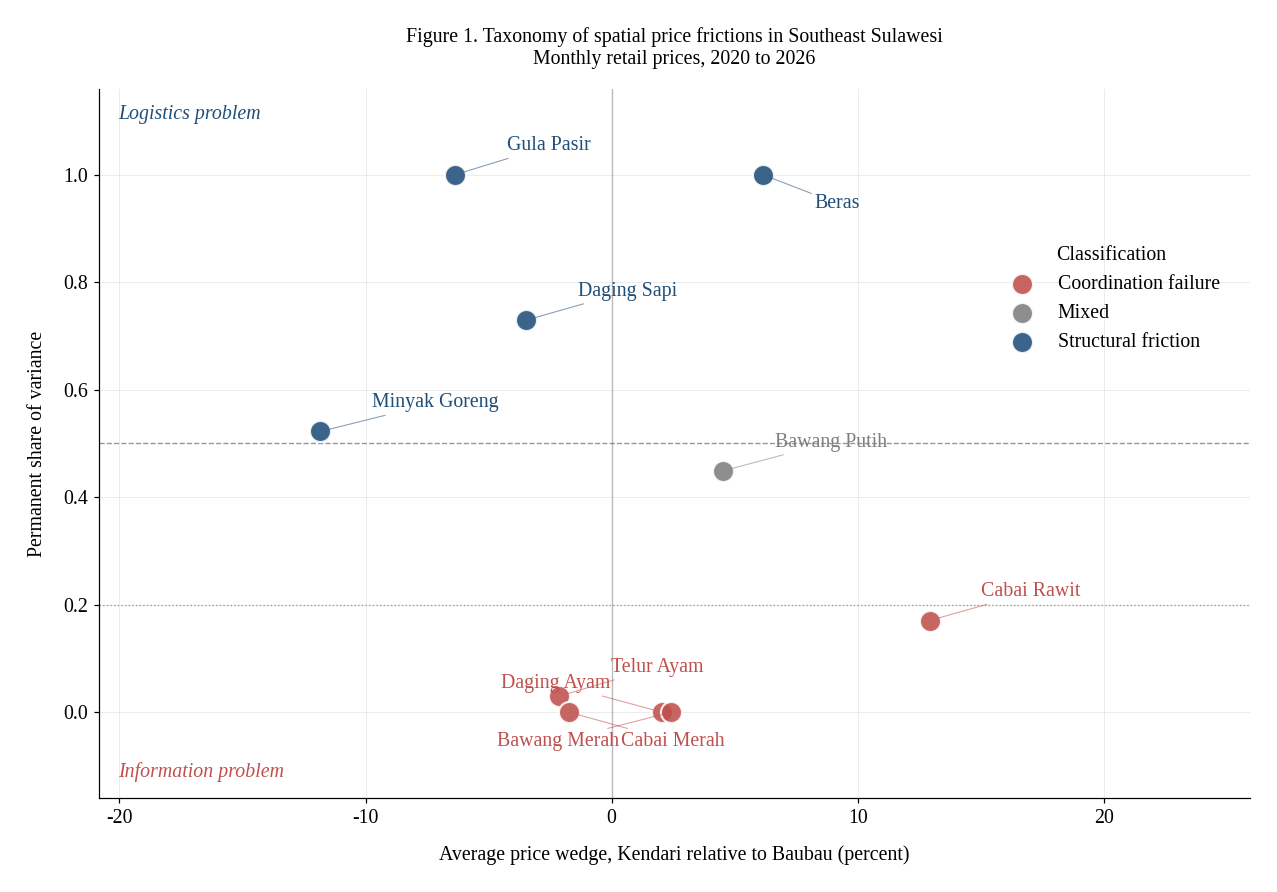

In [ ]:
def atur_label(titik, lebar_x, lebar_y):
    """Menentukan letak label relatif terhadap titiknya.

    Pergeseran dibuat kecil dan tetap agar penunjuk tetap pendek. Arah dipilih
    dari empat kemungkinan secara bergiliran di dalam kelompok titik yang
    berdekatan, sehingga label pada kerumunan tidak saling menutup tanpa harus
    terdorong jauh dari titik asalnya.
    """
    arah_pilihan = [(1, 0.9), (1, -0.9), (-1, 0.9), (-1, -0.9)]
    titik = sorted(titik, key=lambda t: (round(t[1], 1), t[0]))
    letak, sudah = [], {}
    for x, y, teks, warna in titik:
        kunci = round(y, 1)
        i = sudah.get(kunci, 0)
        sudah[kunci] = i + 1
        ax, ay = arah_pilihan[i % 4]
        letak.append((x, y,
                      x + ax * 0.045 * lebar_x,
                      y + ay * 0.045 * lebar_y,
                      teks, warna, ax))
    return letak

fig, sb = plt.subplots(figsize=(11.5, 8.0))
peta_warna = {"Structural friction": WARNA["struktural"],
              "Coordination failure": WARNA["koordinasi"],
              "Mixed": WARNA["campuran"], "Undetermined": WARNA["muda"]}

for gol, kel in TABEL1.groupby("Classification"):
    sb.scatter(kel["Mean wedge (%)"], kel["Permanent share"],
               s=190, alpha=0.88, label=gol, color=peta_warna[gol],
               edgecolors="white", linewidths=1.4, zorder=3)

sb.axhline(0.50, color=WARNA["netral"], lw=0.9, ls="--", alpha=0.55, zorder=1)
sb.axhline(0.20, color=WARNA["netral"], lw=0.9, ls=":",  alpha=0.55, zorder=1)
sb.axvline(0.0,  color=WARNA["netral"], lw=0.9, alpha=0.35, zorder=1)

sb.set_xlabel("Average price wedge, Kendari relative to Baubau (percent)", labelpad=11)
sb.set_ylabel("Permanent share of variance", labelpad=11)
sb.set_title("Figure 1. Taxonomy of spatial price frictions in Southeast Sulawesi\n"
             "Monthly retail prices, 2020 to 2026", pad=16)
sb.set_ylim(-0.16, 1.16)
sb.set_xlim(TABEL1["Mean wedge (%)"].min() - 9, TABEL1["Mean wedge (%)"].max() + 13)

rentang_x = sb.get_xlim()[1] - sb.get_xlim()[0]
rentang_y = sb.get_ylim()[1] - sb.get_ylim()[0]
titik = [(b["Mean wedge (%)"], b["Permanent share"], n, peta_warna[b["Classification"]])
         for n, b in TABEL1.iterrows()]
for x, y, xt, yt, teks, warna, arah in atur_label(titik, rentang_x, rentang_y):
    sb.annotate(teks, xy=(x, y), xytext=(xt, yt), fontsize=13, color=warna,
                ha="left" if arah > 0 else "right", va="center",
                arrowprops=dict(arrowstyle="-", color=warna, lw=0.7, alpha=0.55,
                                shrinkA=0, shrinkB=6))

sb.text(sb.get_xlim()[0] + 0.8, 1.13, "Logistics problem", fontsize=13,
        color=WARNA["struktural"], style="italic", va="top")
sb.text(sb.get_xlim()[0] + 0.8, -0.13, "Information problem", fontsize=13,
        color=WARNA["koordinasi"], style="italic", va="bottom")
sb.legend(loc="upper right", title="Classification", title_fontsize=13,
          borderaxespad=1.1, bbox_to_anchor=(1.0, 0.82))
plt.tight_layout()
fig.savefig(os.path.join(JALUR["04_gambar"], "figure1_friction_taxonomy.png"))
plt.show()

### Gambar kedua, contoh penguraian pada dua komoditas yang berlawanan

Gambar berikut menampilkan satu komoditas dengan pangsa permanen tertinggi dan satu
komoditas dengan pangsa permanen terendah. Garis tebal adalah taraf permanen hasil
penyaringan, sedangkan titik adalah selisih harga yang teramati. Perbedaan pola antara
keduanya adalah inti temuan lapis pertama.


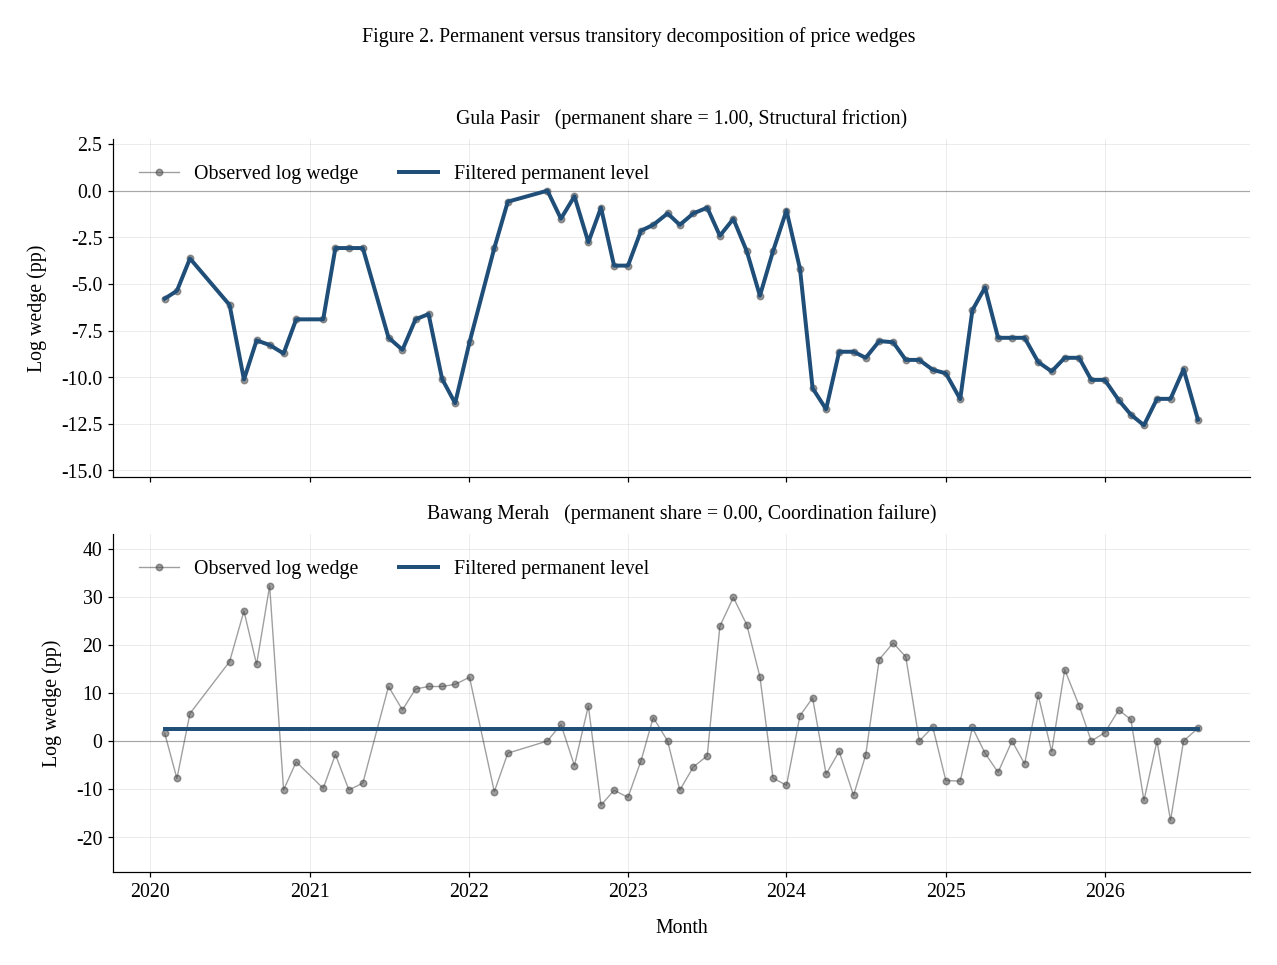

In [ ]:
pilih = [TABEL1.index[0], TABEL1.index[-1]]
fig, sumbu = plt.subplots(2, 1, figsize=(11.5, 8.6), sharex=True)

for ax, nama in zip(sumbu, pilih):
    sub = DATA["selisih"][DATA["selisih"].komoditas == nama].sort_values("tanggal")
    q = sub["selisih_log"].values * 100
    taraf = hasil[nama]["taraf"] * 100
    ax.axhline(0, color=WARNA["netral"], lw=0.8, alpha=0.4)
    ax.plot(sub.tanggal, q, marker="o", ms=4.2, lw=0.9, alpha=0.5,
            color=WARNA["netral"], label="Observed log wedge")
    ax.plot(sub.tanggal[:len(taraf)], taraf, lw=2.6,
            color=WARNA["struktural"], label="Filtered permanent level")
    pi = TABEL1.loc[nama, "Permanent share"]
    ax.set_title("%s   (permanent share = %.2f, %s)"
                 % (nama, pi, TABEL1.loc[nama, "Classification"]), pad=10)
    ax.set_ylabel("Log wedge (pp)", labelpad=9)
    ax.legend(loc="upper left", ncol=2, borderaxespad=0.9)
    ax.margins(y=0.22)

sumbu[-1].set_xlabel("Month", labelpad=11)
fig.suptitle("Figure 2. Permanent versus transitory decomposition of price wedges",
             y=0.985)
plt.tight_layout(rect=[0, 0, 1, 0.965])
fig.savefig(os.path.join(JALUR["04_gambar"], "figure2_wedge_decomposition.png"))
plt.show()

### Menerjemahkan pita friksi menjadi rupiah per kilogram

Pangsa ragam adalah bilangan tanpa satuan sehingga sulit dipakai dalam perhitungan
kebijakan. Untuk keperluan lapis ketiga, selisih permanen diubah menjadi biaya friksi
dalam rupiah per kilogram dengan mengalikan selisih rata rata terhadap harga eceran
rata rata komoditas yang bersangkutan.

$$c_i = \left| e^{\bar{q}_i} - 1 \right| \times \bar{P}_i \times \pi_i$$

Perkalian dengan $\pi_i$ memastikan hanya bagian yang menetap yang diperhitungkan sebagai
biaya perpindahan barang, sedangkan bagian yang bersifat sesaat tidak dimasukkan karena
tidak mencerminkan sumber daya nyata yang terpakai.


In [ ]:
harga_rerata = (DATA["pihps"][DATA["pihps"].is_agregat]
                .groupby("komoditas")["harga_rp"].mean())

BIAYA_FRIKSI = pd.DataFrame({
    "mean_price_idr_kg": harga_rerata,
    "abs_wedge": (TABEL1["Mean wedge (%)"] / 100).abs(),
    "permanent_share": TABEL1["Permanent share"],
}).dropna()
BIAYA_FRIKSI["friction_cost_idr_kg"] = (BIAYA_FRIKSI["abs_wedge"]
                                        * BIAYA_FRIKSI["mean_price_idr_kg"]
                                        * BIAYA_FRIKSI["permanent_share"])
BIAYA_FRIKSI["friction_cost_pct"] = (BIAYA_FRIKSI["friction_cost_idr_kg"]
                                     / BIAYA_FRIKSI["mean_price_idr_kg"] * 100)
BIAYA_FRIKSI = BIAYA_FRIKSI.sort_values("friction_cost_idr_kg", ascending=False)
BIAYA_FRIKSI.index.name = "Commodity"

TABEL2 = BIAYA_FRIKSI.rename(columns={
    "mean_price_idr_kg": "Mean retail price (IDR/kg)",
    "abs_wedge": "Absolute wedge", "permanent_share": "Permanent share",
    "friction_cost_idr_kg": "Structural friction (IDR/kg)",
    "friction_cost_pct": "Structural friction (% of price)"})
print(TABEL2.round(2).to_string())
TABEL2.round(2).to_csv(os.path.join(JALUR["03_tabel"], "table2_friction_cost.csv"))

FRIKSI_RERATA_PCT = float(BIAYA_FRIKSI.loc[
    BIAYA_FRIKSI.permanent_share >= 0.5, "friction_cost_pct"].mean())
print("\nBiaya friksi struktural rata rata pada kelompok logistik: %.2f persen dari harga"
      % FRIKSI_RERATA_PCT)

               Mean retail price (IDR/kg)  Absolute wedge  Permanent share  Structural friction (IDR/kg)  Structural friction (% of price)
Commodity                                                                                                                                 
Daging Sapi                     131934.03            0.03             0.73                       3331.24                              2.52
Cabai Rawit                      57622.92            0.13             0.17                       1270.05                              2.20
Minyak Goreng                    20415.28            0.12             0.52                       1261.91                              6.18
Gula Pasir                       18190.62            0.06             1.00                       1154.64                              6.35
Bawang Putih                     42211.11            0.05             0.45                        854.89                              2.03
Beras                      

## Langkah 5. Lapis kedua, memetakan struktur penjalaran guncangan harga

Lapis pertama memperlakukan setiap pasangan harga secara terpisah. Lapis kedua bertanya
lebih jauh, yaitu bagaimana guncangan pada satu harga di satu kota menjalar ke harga lain
di kota lain. Jawabannya menentukan di titik mana pengendalian harga sebaiknya
dipusatkan.

Alat yang dipakai adalah dekomposisi varians galat ramalan tergeneralisasi yang
diperkenalkan Pesaran dan Shin (1998) dan dijadikan ukuran konektivitas oleh Diebold dan
Yilmaz (2012). Keunggulan bentuk tergeneralisasi adalah hasilnya tidak bergantung pada
urutan peubah, sehingga tidak perlu mengasumsikan siapa yang lebih dahulu memengaruhi
siapa. Asumsi semacam itu sulit dipertahankan pada harga pangan.

Sistem yang dianalisis memuat dua puluh deret, yaitu sepuluh komoditas pada dua kota,
dengan tujuh puluh satu pengamatan bulanan. Jumlah parameter vektor autoregresi biasa
akan melebihi jumlah pengamatan, sehingga pendugaan dilakukan persamaan demi persamaan
dengan penyusutan kuadrat terkecil terpilih mengikuti Demirer, Diebold, Liu, dan Yilmaz
(2018). Tetapan penyusutan dipilih dengan validasi silang lima lipatan.

Dari matriks dekomposisi $\theta_{ij}$ yang telah dinormalkan menurut baris diperoleh tiga
ukuran. Konektivitas yang diterima peubah $i$, konektivitas yang dipancarkan peubah $i$,
dan selisih keduanya yang disebut konektivitas bersih.

$$C_{i \leftarrow \bullet} = \sum_{j \neq i} \tilde{\theta}_{ij}, \qquad
C_{\bullet \leftarrow i} = \sum_{j \neq i} \tilde{\theta}_{ji}, \qquad
C^{net}_i = C_{\bullet \leftarrow i} - C_{i \leftarrow \bullet}$$

Indeks konektivitas total adalah rata rata seluruh unsur di luar diagonal, yang mengukur
seberapa besar pergerakan harga ditentukan oleh guncangan dari luar dirinya sendiri.


In [ ]:
from sklearn.linear_model import LassoCV

def susun_panel_harga(d):
    """Mengubah harga bulanan menjadi matriks pertumbuhan logaritma antar deret."""
    d = d[d.is_agregat].copy()
    d["deret"] = d.kota.str[:3] + "_" + d.komoditas.str.replace(" ", "")
    lebar = d.pivot_table(index="tanggal", columns="deret", values="harga_rp")
    lebar = lebar.interpolate(limit_direction="both")
    return np.log(lebar).diff().dropna() * 100

def var_penyusutan(Y, p=1, benih=0):
    """Vektor autoregresi berdimensi tinggi, diduga persamaan demi persamaan."""
    Y = np.asarray(Y, dtype=float)
    T, N = Y.shape
    X = np.column_stack([Y[p - 1 - i:T - 1 - i] for i in range(p)])
    Yt = Y[p:]
    X = X[:len(Yt)]
    A = np.zeros((N, N * p))
    E = np.zeros_like(Yt)
    for j in range(N):
        m = LassoCV(cv=5, random_state=benih, max_iter=30000, n_alphas=60).fit(X, Yt[:, j])
        A[j] = m.coef_
        E[:, j] = Yt[:, j] - m.predict(X)
    kepadatan = float((A != 0).mean())
    return A, np.cov(E, rowvar=False), kepadatan

def dekomposisi_tergeneralisasi(A, Sigma, p=1, H=12):
    """Dekomposisi varians galat ramalan tergeneralisasi, dinormalkan menurut baris."""
    N = Sigma.shape[0]
    Alist = [A[:, i * N:(i + 1) * N] for i in range(p)]
    Phi = [np.eye(N)]
    for h in range(1, H):
        S = np.zeros((N, N))
        for i in range(1, min(h, p) + 1):
            S += Alist[i - 1] @ Phi[h - i]
        Phi.append(S)
    sd = np.sqrt(np.diag(Sigma))
    theta = np.zeros((N, N))
    for i in range(N):
        penyebut = sum(float(Phi[h][i] @ Sigma @ Phi[h][i]) for h in range(H))
        for j in range(N):
            pembilang = sum(float((Phi[h][i] @ Sigma[:, j]) ** 2) for h in range(H))
            theta[i, j] = pembilang / (sd[j] ** 2 * penyebut)
    return theta / theta.sum(axis=1, keepdims=True)

PANEL_HARGA = susun_panel_harga(DATA["pihps"])
A_VAR, SIGMA_VAR, KEPADATAN = var_penyusutan(PANEL_HARGA.values, p=1)
THETA = dekomposisi_tergeneralisasi(A_VAR, SIGMA_VAR, p=1, H=12)

nama_deret = list(PANEL_HARGA.columns)
TABEL_LIMPAHAN = pd.DataFrame(THETA * 100, index=nama_deret, columns=nama_deret)
menerima = TABEL_LIMPAHAN.sum(axis=1) - np.diag(TABEL_LIMPAHAN)
memancar = TABEL_LIMPAHAN.sum(axis=0) - np.diag(TABEL_LIMPAHAN)
KONEKTIVITAS = pd.DataFrame({"From others": menerima, "To others": memancar,
                             "Net": memancar - menerima}).sort_values("Net",
                                                                     ascending=False)
KONEKTIVITAS.index.name = "Series"
TCI = (TABEL_LIMPAHAN.values.sum() - np.trace(TABEL_LIMPAHAN.values)) / len(nama_deret)

print("Panel harga: %d bulan, %d deret, %s sampai %s"
      % (PANEL_HARGA.shape[0], PANEL_HARGA.shape[1],
         PANEL_HARGA.index.min().date(), PANEL_HARGA.index.max().date()))
print("Kepadatan koefisien setelah penyusutan: %.3f" % KEPADATAN)
print("Indeks konektivitas total: %.2f persen\n" % TCI)
print(KONEKTIVITAS.round(2).to_string())

KONEKTIVITAS.round(2).to_csv(os.path.join(JALUR["03_tabel"],
                             "table3_directional_connectedness.csv"))
TABEL_LIMPAHAN.round(2).to_csv(os.path.join(JALUR["03_tabel"],
                               "table4_spillover_matrix.csv"))

Panel harga: 71 bulan, 20 deret, 2020-03-02 sampai 2026-08-03
Kepadatan koefisien setelah penyusutan: 0.172
Indeks konektivitas total: 54.60 persen

                  From others  To others    Net
Series                                         
Ken_MinyakGoreng        61.30     109.82  48.52
Bau_MinyakGoreng        60.57     108.90  48.33
Ken_CabaiMerah          58.54      82.83  24.29
Bau_GulaPasir           60.40      73.46  13.07
Bau_CabaiMerah          54.09      65.22  11.13
Ken_DagingSapi          50.15      59.54   9.39
Ken_CabaiRawit          51.31      56.79   5.48
Ken_GulaPasir           56.04      58.48   2.44
Bau_CabaiRawit          47.77      49.60   1.84
Ken_Beras               55.91      56.53   0.63
Bau_Beras               54.72      54.23  -0.50
Ken_TelurAyam           49.18      47.48  -1.69
Ken_DagingAyam          36.25      30.22  -6.02
Bau_TelurAyam           58.56      49.18  -9.38
Bau_BawangMerah         53.04      42.18 -10.86
Bau_DagingAyam          36.99      

### Menguji dugaan kota pusat

Dugaan yang lazim adalah Kendari berperan sebagai kota pusat yang menyalurkan guncangan
harga ke wilayah lain. Dugaan itu diuji dengan menjumlahkan unsur matriks limpahan
menurut blok kota, lalu membandingkan arus dari Kendari ke Baubau dengan arus sebaliknya.

Jika rasio kedua arus mendekati satu, dugaan kota pusat tidak didukung data. Kesimpulan
semacam itu memiliki makna kebijakan tersendiri, karena berarti kedua kota adalah penerima
sejajar dari guncangan yang berasal dari luar provinsi, bukan mata rantai yang saling
menyuplai.


In [ ]:
kota_deret = pd.Series([s[:3] for s in nama_deret], index=nama_deret)
BLOK = (TABEL_LIMPAHAN.T.groupby(kota_deret).sum().T.groupby(kota_deret).sum())
BLOK.index = ["Baubau (receiver)", "Kendari (receiver)"]
BLOK.columns = ["Baubau (source)", "Kendari (source)"]

total_blok = BLOK.values.sum()
ken_ke_bau = BLOK.loc["Baubau (receiver)", "Kendari (source)"]
bau_ke_ken = BLOK.loc["Kendari (receiver)", "Baubau (source)"]
dalam_bau = BLOK.loc["Baubau (receiver)", "Baubau (source)"]
dalam_ken = BLOK.loc["Kendari (receiver)", "Kendari (source)"]
RASIO_PUSAT = ken_ke_bau / bau_ke_ken

TABEL5 = BLOK.round(2)
print(TABEL5.to_string())
print("\nKendari ke Baubau : %.2f persen dari total" % (ken_ke_bau / total_blok * 100))
print("Baubau ke Kendari : %.2f persen dari total" % (bau_ke_ken / total_blok * 100))
print("Limpahan di dalam kota sendiri: Baubau %.2f persen, Kendari %.2f persen"
      % (dalam_bau / total_blok * 100, dalam_ken / total_blok * 100))
print("Rasio dominasi Kendari terhadap Baubau: %.3f" % RASIO_PUSAT)
TABEL5.to_csv(os.path.join(JALUR["03_tabel"], "table5_intercity_block.csv"))

                    Baubau (source)  Kendari (source)
Baubau (receiver)            624.48            375.52
Kendari (receiver)           358.20            641.80

Kendari ke Baubau : 18.78 persen dari total
Baubau ke Kendari : 17.91 persen dari total
Limpahan di dalam kota sendiri: Baubau 31.22 persen, Kendari 32.09 persen
Rasio dominasi Kendari terhadap Baubau: 1.048


### Gambar ketiga, konektivitas bersih menurut deret harga

Batang yang menjulur ke kanan menandakan deret yang lebih banyak memancarkan guncangan
daripada menerimanya, sehingga layak diperlakukan sebagai sumber yang perlu diawasi.
Batang yang menjulur ke kiri menandakan deret yang terutama menerima, sehingga
pengendalian pada deret itu sendiri tidak akan banyak berguna.


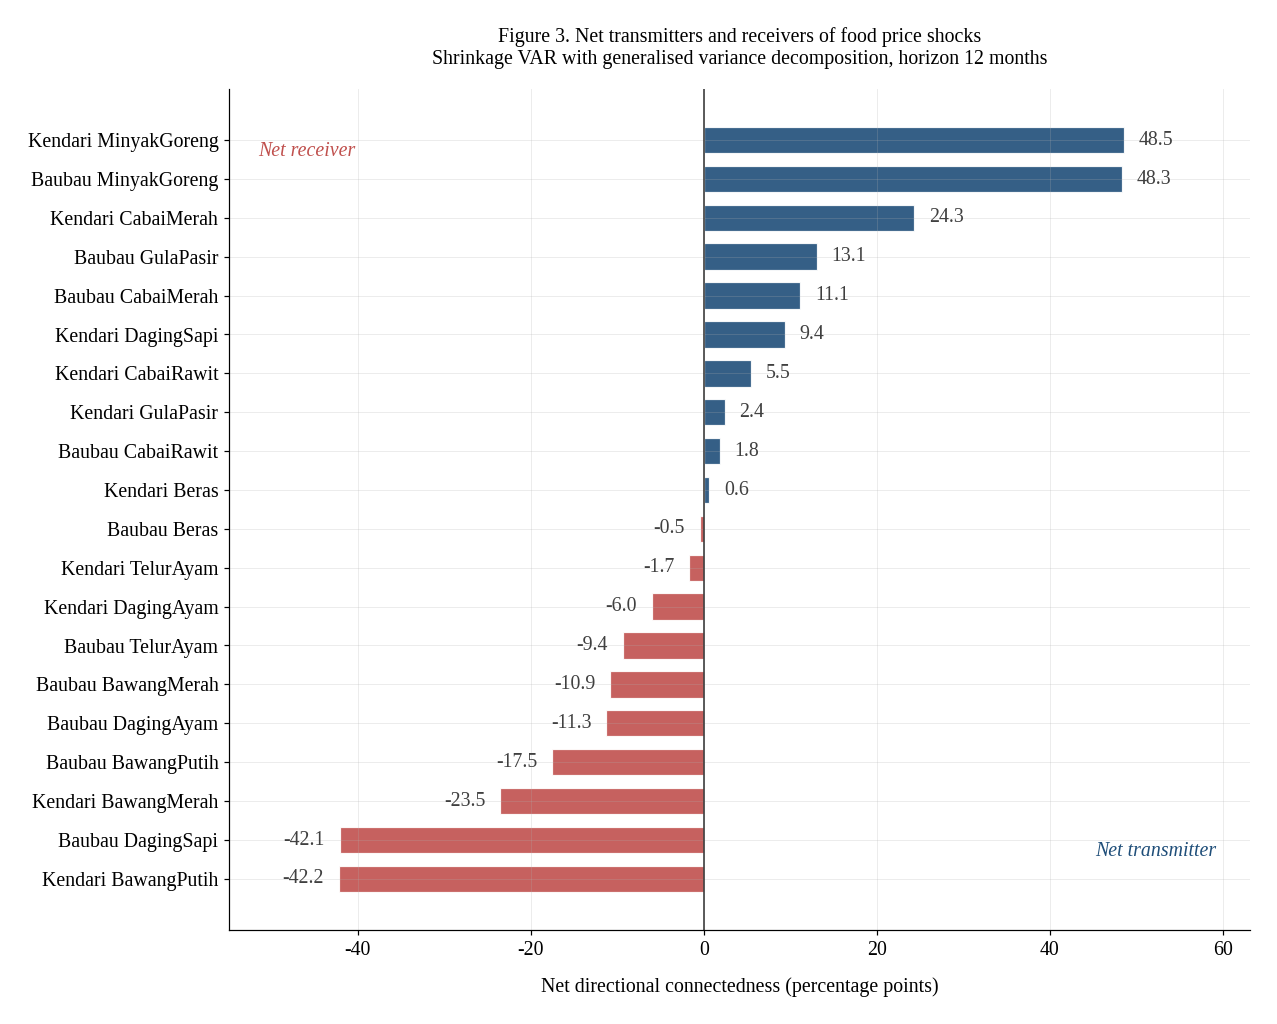

In [ ]:
urut = KONEKTIVITAS.sort_values("Net")
warna_batang = [WARNA["struktural"] if v > 0 else WARNA["koordinasi"]
                for v in urut["Net"]]

fig, sb = plt.subplots(figsize=(11.5, 9.2))
posisi = np.arange(len(urut))
sb.barh(posisi, urut["Net"], color=warna_batang, alpha=0.9, height=0.68,
        edgecolor="white", linewidth=0.8)
sb.set_yticks(posisi)
sb.set_yticklabels([s.replace("Ken_", "Kendari ").replace("Bau_", "Baubau ")
                    for s in urut.index])
sb.axvline(0, color=WARNA["netral"], lw=1.1)
sb.set_xlabel("Net directional connectedness (percentage points)", labelpad=11)
sb.set_title("Figure 3. Net transmitters and receivers of food price shocks\n"
             "Shrinkage VAR with generalised variance decomposition, horizon 12 months",
             pad=16)

jarak = max(abs(urut["Net"])) * 0.035
for i, v in enumerate(urut["Net"]):
    sb.text(v + (jarak if v >= 0 else -jarak), i, "%.1f" % v,
            va="center", ha="left" if v >= 0 else "right", fontsize=13,
            color=WARNA["netral"])

sb.set_xlim(min(urut["Net"]) * 1.30, max(urut["Net"]) * 1.30)
sb.text(max(urut["Net"]) * 1.22, 0.6, "Net transmitter", fontsize=13, style="italic",
        color=WARNA["struktural"], ha="right")
sb.text(min(urut["Net"]) * 1.22, len(urut) - 1.4, "Net receiver", fontsize=13,
        style="italic", color=WARNA["koordinasi"], ha="left")
plt.tight_layout()
fig.savefig(os.path.join(JALUR["04_gambar"], "figure3_net_connectedness.png"))
plt.show()

### Gambar keempat, matriks limpahan dalam bentuk peta panas

Peta panas menampilkan seluruh matriks dekomposisi. Baris adalah penerima dan kolom adalah
sumber. Warna yang pekat di sepanjang diagonal menandakan guncangan yang tetap tinggal di
dalam deretnya sendiri, sedangkan warna pekat di luar diagonal menandakan penjalaran.


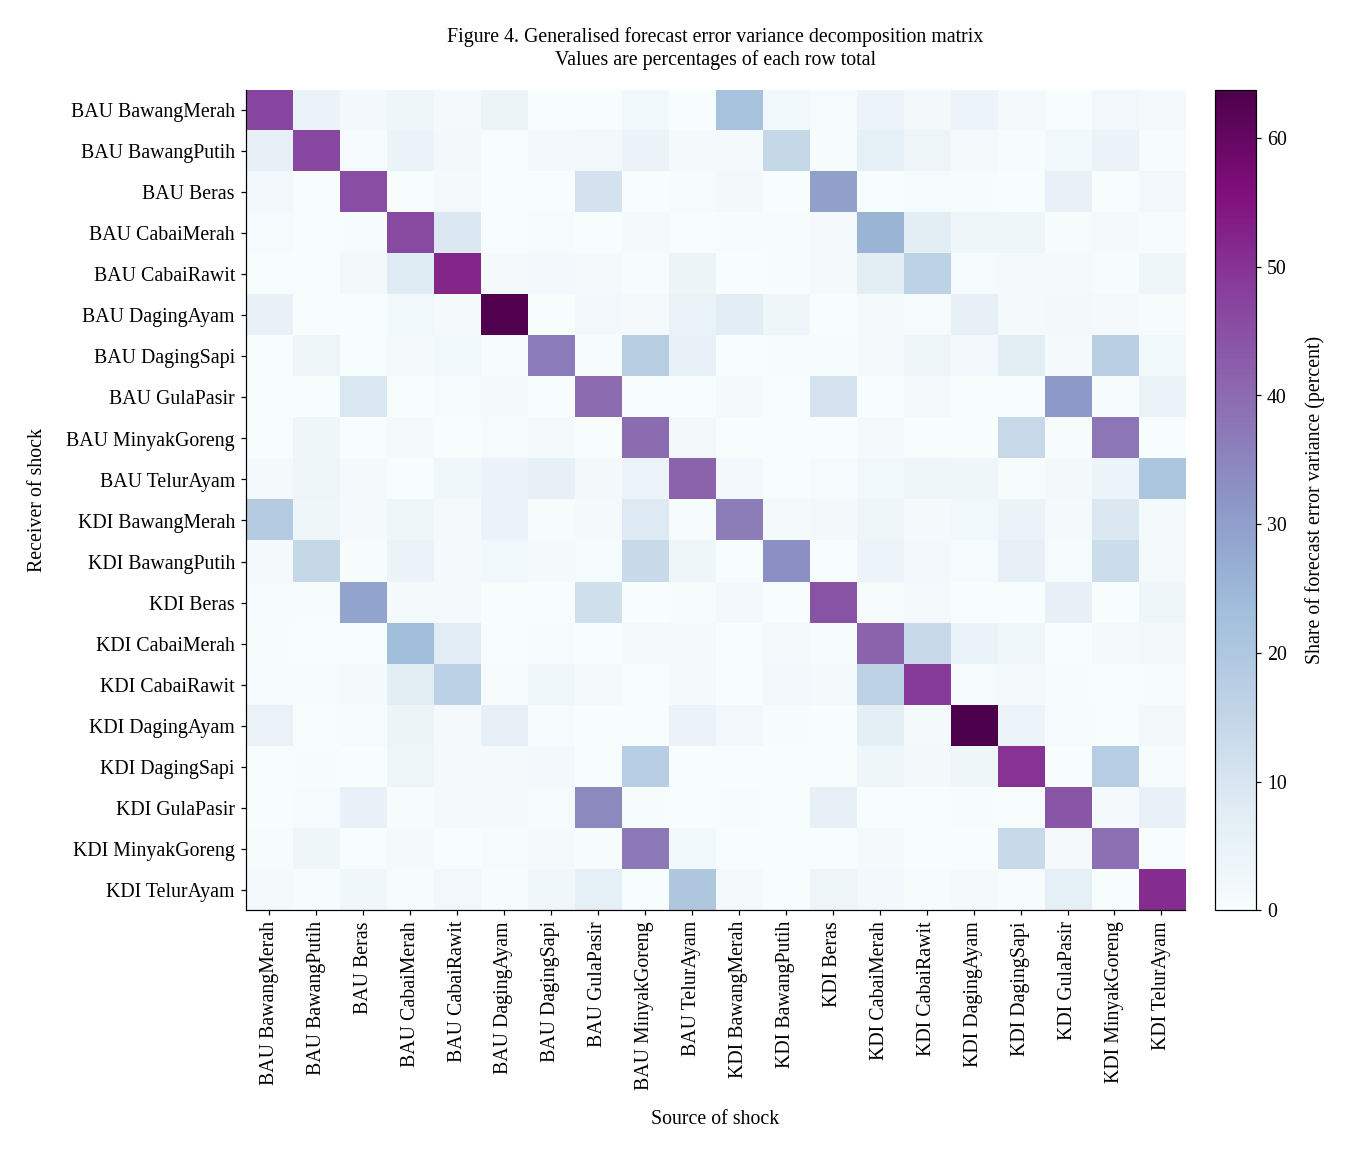

In [ ]:
label_pendek = [s.replace("Ken_", "KDI ").replace("Bau_", "BAU ") for s in nama_deret]
fig, sb = plt.subplots(figsize=(12.2, 10.4))
gbr = sb.imshow(TABEL_LIMPAHAN.values, cmap="BuPu", aspect="auto", vmin=0)

sb.set_xticks(np.arange(len(label_pendek)))
sb.set_yticks(np.arange(len(label_pendek)))
sb.set_xticklabels(label_pendek, rotation=90, fontsize=13)
sb.set_yticklabels(label_pendek, fontsize=13)
sb.set_xlabel("Source of shock", labelpad=13)
sb.set_ylabel("Receiver of shock", labelpad=13)
sb.set_title("Figure 4. Generalised forecast error variance decomposition matrix\n"
             "Values are percentages of each row total", pad=16)
sb.grid(False)

bar = fig.colorbar(gbr, ax=sb, fraction=0.042, pad=0.03)
bar.set_label("Share of forecast error variance (percent)", labelpad=12, fontsize=13)
bar.ax.tick_params(labelsize=13)
plt.tight_layout()
fig.savefig(os.path.join(JALUR["04_gambar"], "figure4_spillover_matrix.png"))
plt.show()

## Langkah 6. Tangga nilai perikanan dan besar nilai yang tidak tertangkap

Dua lapis pertama menjelaskan mengapa harga pangan di Sulawesi Tenggara mahal dan tidak
stabil. Langkah ini menjelaskan sisi yang berlawanan, yaitu mengapa pendapatan produsen
tetap rendah meskipun produksinya besar.

Perbandingan dilakukan pada tiga anak tangga. Anak tangga pertama adalah harga yang
diterima produsen di tingkat provinsi. Anak tangga kedua adalah nilai satuan ekspor ikan
dalam bentuk mentah pada pos tarif tiga. Anak tangga ketiga adalah nilai satuan ekspor
olahan daging dan ikan pada pos tarif enam belas.

Nilai satuan dihitung sebagai hasil bagi nilai terhadap volume pada tingkat tahunan
sehingga tidak terpengaruh oleh perbedaan waktu pencatatan. Konversi ke rupiah memakai
kurs rata rata bulanan yang tercantum pada berkas sumber yang sama, sehingga angka nilai
dan angka kurs berasal dari satu proses pengolahan dan tetap sinkron.

Perlu dicatat bahwa pos tarif tiga memuat pula udang dan biota bernilai tinggi lain,
sehingga perbandingan terhadap harga ikan tongkol bersifat menunjukkan arah, bukan
kesetaraan jenis. Batasan ini disebutkan secara terbuka karena memengaruhi cara
membaca selisihnya.


In [ ]:
HS_MENTAH, HS_OLAHAN = 3, 16
VOLUME_MINIMUM_KG = 25_000      # ambang keandalan nilai satuan tahunan

def ringkas_pos(d, hs):
    sub = d[d.hs == hs].copy()
    sub = sub.set_index("tanggal")[["usd", "kg"]].sort_index()
    tahunan = sub.resample("YE").sum()
    # Tahun dengan volume sangat kecil menghasilkan nilai satuan yang tidak stabil
    # karena pembaginya mendekati nol, sehingga disaring lebih dahulu.
    tahunan = tahunan[(tahunan["usd"] > 0) & (tahunan["kg"] >= VOLUME_MINIMUM_KG)]
    tahunan["usd_per_kg"] = np.where(tahunan["kg"] > 0,
                                     tahunan["usd"] / tahunan["kg"], np.nan)
    tahunan["ton"] = tahunan["kg"] / 1000.0
    tahunan.index = tahunan.index.year
    return tahunan

kurs_tahunan = DATA["kurs"].groupby(DATA["kurs"].index.year).mean()
mentah = ringkas_pos(DATA["ekspor"], HS_MENTAH)
olahan = ringkas_pos(DATA["ekspor"], HS_OLAHAN)

TANGGA = pd.DataFrame({
    "Raw fish value (USD)": mentah["usd"],
    "Raw fish volume (tonnes)": mentah["ton"],
    "Raw fish unit value (USD/kg)": mentah["usd_per_kg"],
    "Processed value (USD)": olahan["usd"],
    "Processed volume (tonnes)": olahan["ton"],
    "Processed unit value (USD/kg)": olahan["usd_per_kg"],
    "Exchange rate (IDR/USD)": kurs_tahunan,
}).dropna(subset=["Raw fish unit value (USD/kg)"])
TANGGA["Processing premium (times)"] = (TANGGA["Processed unit value (USD/kg)"]
                                        / TANGGA["Raw fish unit value (USD/kg)"])
TANGGA["Raw fish unit value (IDR/kg)"] = (TANGGA["Raw fish unit value (USD/kg)"]
                                          * TANGGA["Exchange rate (IDR/USD)"])
TANGGA["Processed unit value (IDR/kg)"] = (TANGGA["Processed unit value (USD/kg)"]
                                           * TANGGA["Exchange rate (IDR/USD)"])
TANGGA.index.name = "Year"

TABEL6 = TANGGA.round(2)
print(TABEL6.to_string())
TABEL6.to_csv(os.path.join(JALUR["03_tabel"], "table6_fishery_value_ladder.csv"))

# harga produsen dan nilai yang tidak tertangkap
harga_produsen = DATA["tongkol"][DATA["tongkol"].level_harga == "produsen"]
HARGA_PRODUSEN = float(harga_produsen.harga_rp_kg.mean())
tahun_akhir = int(TANGGA.index.max())
tahun_penuh = int(TANGGA.index[TANGGA.index < TANGGA.index.max()].max())

baris = TANGGA.loc[tahun_penuh]
NILAI_EKSPOR_IKAN_IDR = ((baris["Raw fish value (USD)"] + baris["Processed value (USD)"])
                         * baris["Exchange rate (IDR/USD)"])
PREMI_OLAHAN = float(baris["Processing premium (times)"])
print("\nHarga produsen ikan tongkol rata rata 2022 sampai 2024: Rp%s per kilogram"
      % format(HARGA_PRODUSEN, ",.0f"))
print("Tahun penuh terakhir yang dipakai sebagai acuan: %d" % tahun_penuh)
print("Nilai ekspor perikanan %d: Rp%s (%.3f triliun)"
      % (tahun_penuh, format(NILAI_EKSPOR_IKAN_IDR, ",.0f"),
         NILAI_EKSPOR_IKAN_IDR / 1e12))
print("Premi pengolahan %d: %.2f kali nilai satuan bahan mentah"
      % (tahun_penuh, PREMI_OLAHAN))

      Raw fish value (USD)  Raw fish volume (tonnes)  Raw fish unit value (USD/kg)  Processed value (USD)  Processed volume (tonnes)  Processed unit value (USD/kg)  Exchange rate (IDR/USD)  Processing premium (times)  Raw fish unit value (IDR/kg)  Processed unit value (IDR/kg)
Year                                                                                                                                                                                                                                                                                 
2020           20097559.61                   3038.02                          6.62                    NaN                        NaN                            NaN                 14509.29                         NaN                      95983.97                            NaN
2021           29859594.56                   3644.18                          8.19             2096548.10                      48.59                          43.15   

### Gambar kelima, tangga nilai perikanan

Grafik batang menampilkan tiga anak tangga pada tahun penuh terakhir. Skala tegak dibuat
seragam dalam rupiah per kilogram agar besaran selisihnya terbaca langsung tanpa perlu
menghitung.


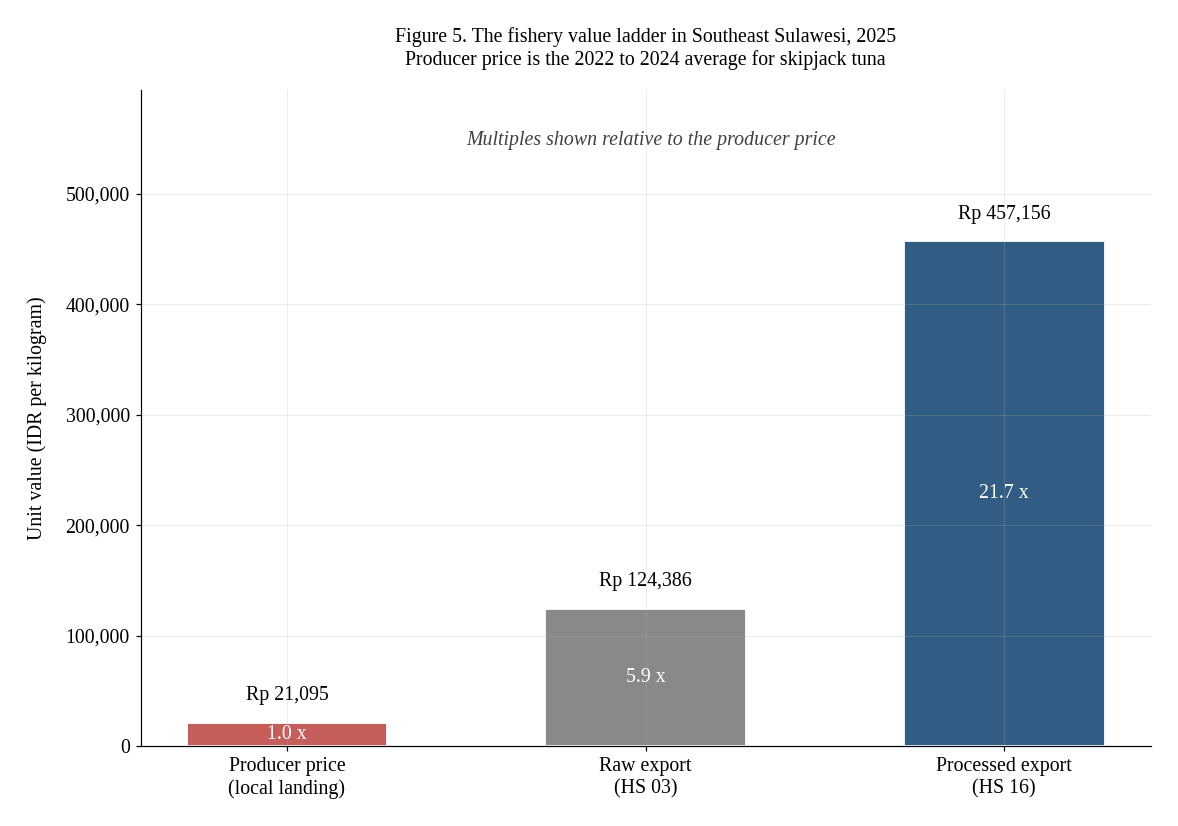

In [ ]:
anak_tangga = pd.Series({
    "Producer price\n(local landing)": HARGA_PRODUSEN,
    "Raw export\n(HS 03)": baris["Raw fish unit value (IDR/kg)"],
    "Processed export\n(HS 16)": baris["Processed unit value (IDR/kg)"],
})

fig, sb = plt.subplots(figsize=(10.6, 7.4))
warna_tangga = [WARNA["koordinasi"], WARNA["campuran"], WARNA["struktural"]]
batang = sb.bar(range(len(anak_tangga)), anak_tangga.values, width=0.56,
                color=warna_tangga, alpha=0.92, edgecolor="white", linewidth=1.3)
sb.set_xticks(range(len(anak_tangga)))
sb.set_xticklabels(anak_tangga.index)
sb.set_ylabel("Unit value (IDR per kilogram)", labelpad=12)
sb.set_title("Figure 5. The fishery value ladder in Southeast Sulawesi, %d\n"
             "Producer price is the 2022 to 2024 average for skipjack tuna" % tahun_penuh,
             pad=16)
sb.set_ylim(0, anak_tangga.max() * 1.30)
sb.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
    lambda v, _: format(int(v), ",")))

for b, v in zip(batang, anak_tangga.values):
    sb.text(b.get_x() + b.get_width() / 2, v + anak_tangga.max() * 0.035,
            "Rp %s" % format(int(round(v)), ","), ha="center", va="bottom", fontsize=13)
    lipat = v / anak_tangga.iloc[0]
    sb.text(b.get_x() + b.get_width() / 2, v * 0.5, "%.1f x" % lipat,
            ha="center", va="center", fontsize=13, color="white")

sb.text(0.5, anak_tangga.max() * 1.19,
        "Multiples shown relative to the producer price",
        fontsize=13, style="italic", color=WARNA["netral"])
plt.tight_layout()
fig.savefig(os.path.join(JALUR["04_gambar"], "figure5_value_ladder.png"))
plt.show()

### Gambar keenam, perkembangan volume mentah dan olahan

Grafik ini menunjukkan bahwa kemampuan mengolah sudah ada dan tumbuh, tetapi besarannya
masih sangat kecil dibandingkan volume yang dikirim dalam bentuk mentah. Sumbu tegak
sebelah kiri dan kanan dibedakan skalanya karena rentang keduanya berbeda jauh.


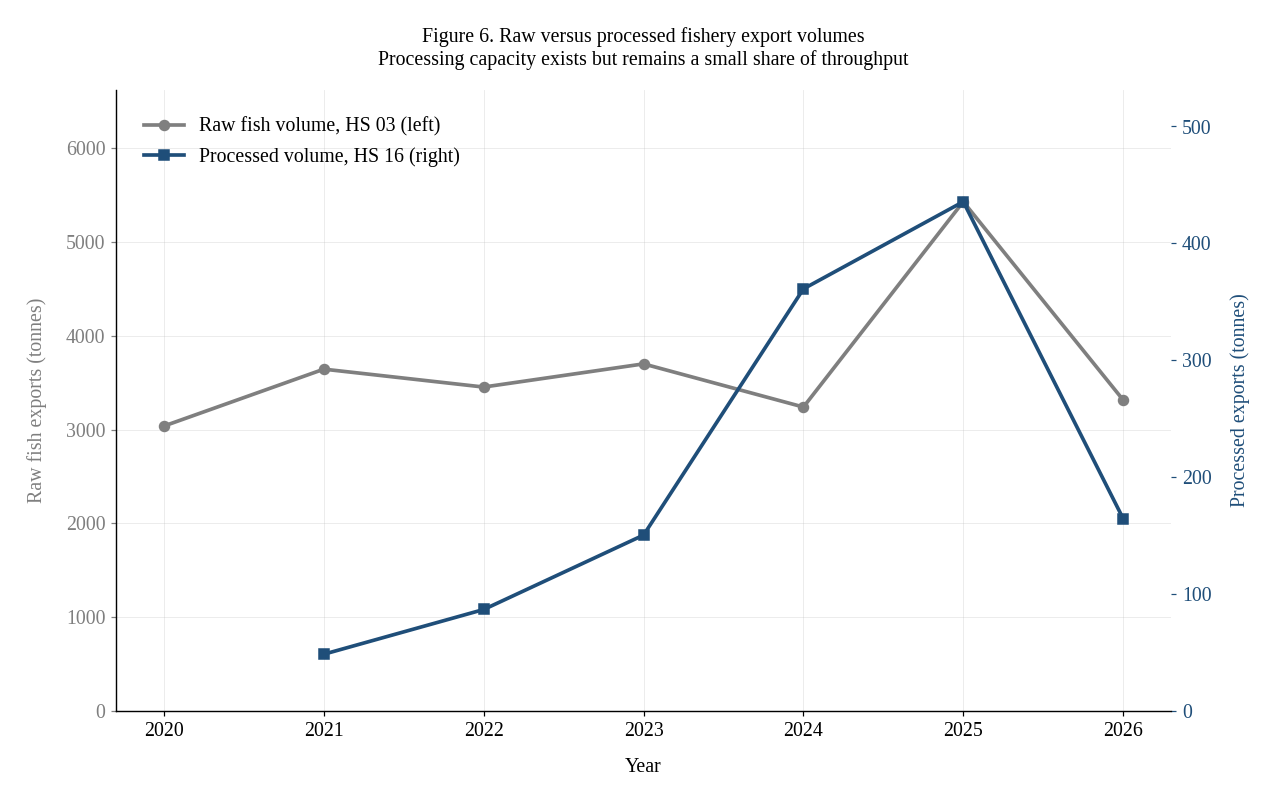

In [ ]:
fig, sb = plt.subplots(figsize=(11.5, 7.2))
sb2 = sb.twinx()
sb2.grid(False)

garis1 = sb.plot(TANGGA.index, TANGGA["Raw fish volume (tonnes)"], marker="o", ms=6.5,
                 lw=2.4, color=WARNA["campuran"], label="Raw fish volume, HS 03 (left)")
garis2 = sb2.plot(TANGGA.index, TANGGA["Processed volume (tonnes)"], marker="s", ms=6.5,
                  lw=2.4, color=WARNA["struktural"],
                  label="Processed volume, HS 16 (right)")

sb.set_xlabel("Year", labelpad=11)
sb.set_ylabel("Raw fish exports (tonnes)", labelpad=12, color=WARNA["campuran"])
sb2.set_ylabel("Processed exports (tonnes)", labelpad=12, color=WARNA["struktural"])
sb.tick_params(axis="y", colors=WARNA["campuran"])
sb2.tick_params(axis="y", colors=WARNA["struktural"])
sb.set_ylim(0, TANGGA["Raw fish volume (tonnes)"].max() * 1.22)
sb2.set_ylim(0, TANGGA["Processed volume (tonnes)"].max() * 1.22)
sb.set_xticks(list(TANGGA.index))
sb.set_title("Figure 6. Raw versus processed fishery export volumes\n"
             "Processing capacity exists but remains a small share of throughput", pad=16)

semua = garis1 + garis2
sb.legend(semua, [g.get_label() for g in semua], loc="upper left", borderaxespad=1.0)
plt.tight_layout()
fig.savefig(os.path.join(JALUR["04_gambar"], "figure6_raw_vs_processed.png"))
plt.show()

## Langkah 7. Lapis ketiga, merancang alokasi permintaan terjamin

Program Makan Bergizi Gratis menciptakan permintaan bahan pangan yang besar, pasti, dan
berulang setiap hari sekolah. Permintaan semacam ini jarang tersedia bagi produsen kecil.
Pertanyaan rancangannya adalah bagaimana permintaan tersebut dialokasikan agar sebanyak
mungkin nilainya tertahan di dalam provinsi tanpa mengganggu kestabilan harga.

Persoalan disusun sebagai pemrograman linear. Notasi $j$ menandai kabupaten pemasok,
$k$ menandai kabupaten tempat dapur berada, $x_{jk}$ menandai jumlah ikan dalam ton yang
dikirim dari $j$ ke $k$, dan $z_k$ menandai jumlah yang didatangkan dari luar provinsi.

Fungsi tujuan meminimumkan biaya pengadaan seluruh sistem.

$$\min_{x, z} \; \sum_{j}\sum_{k} \left( p + c_{jk} \right) x_{jk} \; + \; \sum_{k} \left( p^{luar} + c^{luar} \right) z_k$$

Kendala pertama menjamin kebutuhan setiap kabupaten terpenuhi.

$$\sum_{j} x_{jk} + z_k = D_k \qquad \text{untuk setiap } k$$

Kendala kedua membatasi serapan agar tidak melampaui kemampuan pasokan setempat. Batas
$\phi$ adalah pangsa produksi tahunan yang boleh diserap program.

$$\sum_{k} x_{jk} \le \phi \, S_j \qquad \text{untuk setiap } j$$

Biaya perpindahan $c_{jk}$ disusun bertingkat. Pengiriman di dalam kabupaten yang sama
tidak dikenai biaya perpindahan. Pengiriman antarkabupaten dalam satu gugus geografis
dikenai biaya sebesar tarif friksi hasil lapis pertama. Pengiriman antargugus, yang
berarti menyeberangi laut, dikenai kelipatan dari tarif tersebut. Pendatangan dari luar
provinsi dikenai biaya tertinggi.

Struktur bertingkat ini dipilih karena matriks jarak antarkabupaten tidak tersedia pada
kumpulan data yang ada. Menyusun matriks jarak dari sumber lain akan menambah asumsi yang
tidak dapat diverifikasi dengan data yang sedang dipakai, sehingga pendekatan bertingkat
yang lebih sederhana justru lebih dapat dipertanggungjawabkan.


In [ ]:
from scipy.optimize import linprog

par = DATA["parameter"].set_index("parameter")["nilai"]
PENERIMA_MBG   = float(par["Penerima_manfaat"])
BAHAN_BAKU_MIN = float(par["Komponen_bahan_baku_min"])
BAHAN_BAKU_MAK = float(par["Komponen_bahan_baku_max"])
JUMLAH_SPPG    = float(par["SPPG_Sultra"])
MITRA_PEMASOK  = float(par["Mitra_pemasok"])
HARI_LAYANAN   = 250.0          # asumsi hari sekolah efektif setahun
PANGSA_IKAN    = 0.25           # asumsi pangsa ikan dalam nilai bahan baku
GRAM_IKAN      = 0.050          # asumsi berat ikan per porsi dalam kilogram

ANGGARAN_MIN = PENERIMA_MBG * BAHAN_BAKU_MIN * HARI_LAYANAN
ANGGARAN_MAK = PENERIMA_MBG * BAHAN_BAKU_MAK * HARI_LAYANAN
KEBUTUHAN_IKAN_TON = PENERIMA_MBG * GRAM_IKAN * HARI_LAYANAN / 1000.0

ANGGARAN_IKAN_MIN = ANGGARAN_MIN * PANGSA_IKAN
ANGGARAN_IKAN_MAK = ANGGARAN_MAK * PANGSA_IKAN

print("Anggaran bahan baku setahun : Rp%.3f sampai %.3f triliun"
      % (ANGGARAN_MIN / 1e12, ANGGARAN_MAK / 1e12))
print("Anggaran khusus ikan        : Rp%.3f sampai %.3f triliun"
      % (ANGGARAN_IKAN_MIN / 1e12, ANGGARAN_IKAN_MAK / 1e12))
print("Kebutuhan ikan setahun      : %s ton" % format(KEBUTUHAN_IKAN_TON, ",.0f"))
print("Catatan: pangsa ikan dan berat per porsi adalah asumsi rancangan,")
print("bukan angka resmi, sehingga diuji ulang pada analisis kepekaan.")

Anggaran bahan baku setahun : Rp1.335 sampai 1.668 triliun
Anggaran khusus ikan        : Rp0.334 sampai 0.417 triliun
Kebutuhan ikan setahun      : 8,341 ton
Catatan: pangsa ikan dan berat per porsi adalah asumsi rancangan,
bukan angka resmi, sehingga diuji ulang pada analisis kepekaan.


### Menyusun parameter ruang

Permintaan setiap kabupaten didekati dengan pangsa penduduk, karena jumlah dapur dan
penerima manfaat mengikuti sebaran penduduk usia sekolah. Kapasitas pasokan diambil dari
produksi perikanan tangkap laut menurut kabupaten pada tahun pelaporan terakhir yang
lengkap. Kabupaten tanpa garis pantai laut diberi kapasitas nol, yang merupakan keadaan
sebenarnya dan bukan data hilang.

Ketidaksesuaian ruang diukur sebagai selisih antara pangsa produksi dan pangsa penduduk.
Nilai positif menandakan kabupaten yang menghasilkan lebih banyak daripada yang
dibutuhkannya sendiri, sehingga berpotensi menjadi pemasok bagi kabupaten lain.


In [ ]:
penduduk = DATA["penduduk"].set_index("wilayah")["penduduk"]
tahun_ikan = int(DATA["perikanan"].dropna(subset=["produksi_ton"]).tahun.max())
produksi = (DATA["perikanan"][DATA["perikanan"].tahun == tahun_ikan]
            .set_index("wilayah")["produksi_ton"])

RUANG = pd.DataFrame({"population": penduduk}).join(produksi.rename("fishery_tonnes"))
RUANG["fishery_tonnes"] = RUANG["fishery_tonnes"].fillna(0.0)
RUANG["demand_share"] = RUANG["population"] / RUANG["population"].sum()
RUANG["supply_share"] = RUANG["fishery_tonnes"] / RUANG["fishery_tonnes"].sum()
RUANG["mismatch"] = RUANG["supply_share"] - RUANG["demand_share"]
RUANG["cluster"] = [GUGUS.get(w, "daratan") for w in RUANG.index]
RUANG["demand_tonnes"] = RUANG["demand_share"] * KEBUTUHAN_IKAN_TON
RUANG = RUANG.sort_values("mismatch", ascending=False)
RUANG.index.name = "District"

TABEL7 = RUANG.rename(columns={
    "population": "Population 2026", "fishery_tonnes": "Marine catch (tonnes, %d)" % tahun_ikan,
    "demand_share": "Demand share", "supply_share": "Supply share",
    "mismatch": "Spatial mismatch", "cluster": "Geographic cluster",
    "demand_tonnes": "MBG fish demand (tonnes)"})
print(TABEL7.round(4).to_string())
TABEL7.round(4).to_csv(os.path.join(JALUR["03_tabel"], "table7_spatial_mismatch.csv"))

INDEKS_KETIDAKSESUAIAN = float(RUANG["mismatch"].abs().sum() / 2)
print("\nIndeks ketidaksesuaian ruang: %.4f" % INDEKS_KETIDAKSESUAIAN)
print("Nilai ini menyatakan pangsa produksi yang harus berpindah kabupaten")
print("agar sebaran pasokan sama persis dengan sebaran kebutuhan.")

                  Population 2026  Marine catch (tonnes, 2018)  Demand share  Supply share  Spatial mismatch Geographic cluster  MBG fish demand (tonnes)
District                                                                                                                                                 
Buton Selatan            104400.0                     36654.74        0.0362        0.1794            0.1431          kepulauan                  302.3715
Buton                    125650.0                     26155.04        0.0436        0.1280            0.0844          kepulauan                  363.9175
Konawe Utara              76970.0                     14765.56        0.0267        0.0723            0.0455            daratan                  222.9266
Buton Tengah             124930.0                     17393.17        0.0434        0.0851            0.0417          kepulauan                  361.8321
Buton Utara               71410.0                      8498.88        0.0248

In [ ]:
# ---------------------------------------------------------------
# Penyusunan dan penyelesaian program linear
# ---------------------------------------------------------------
HARGA_LOKAL   = HARGA_PRODUSEN                     # rupiah per kilogram di titik pendaratan
PREMI_LUAR    = 0.15                               # harga dari luar provinsi lebih tinggi
HARGA_LUAR    = HARGA_LOKAL * (1 + PREMI_LUAR)
TARIF_FRIKSI  = HARGA_LOKAL * FRIKSI_RERATA_PCT / 100.0   # dari lapis pertama
LIPAT_ANTARGUGUS = 2.0
LIPAT_LUAR       = 3.0

wil = list(RUANG.index)
n = len(wil)
gugus = RUANG["cluster"].to_dict()

def biaya_kirim(j, k):
    if j == k:
        return 0.0
    return TARIF_FRIKSI * (1.0 if gugus[j] == gugus[k] else LIPAT_ANTARGUGUS)

def selesaikan(phi, tarif=TARIF_FRIKSI, harga_luar=HARGA_LUAR):
    """phi adalah pangsa produksi kabupaten yang boleh diserap program."""
    biaya = []
    for j in wil:
        for k in wil:
            dasar = 0.0 if j == k else tarif * (1.0 if gugus[j] == gugus[k] else LIPAT_ANTARGUGUS)
            biaya.append((HARGA_LOKAL + dasar) * 1000.0)      # rupiah per ton
    biaya += [(harga_luar + tarif * LIPAT_LUAR) * 1000.0] * n
    c = np.array(biaya, dtype=float)

    # kendala kesetaraan: kebutuhan tiap kabupaten terpenuhi
    Aeq = np.zeros((n, n * n + n))
    beq = RUANG["demand_tonnes"].values.astype(float)
    for idx_k in range(n):
        for idx_j in range(n):
            Aeq[idx_k, idx_j * n + idx_k] = 1.0
        Aeq[idx_k, n * n + idx_k] = 1.0

    # kendala pertidaksamaan: batas serapan pasokan setempat
    Aub = np.zeros((n, n * n + n))
    bub = (RUANG["fishery_tonnes"].values * phi).astype(float)
    for idx_j in range(n):
        for idx_k in range(n):
            Aub[idx_j, idx_j * n + idx_k] = 1.0

    hasil = linprog(c, A_ub=Aub, b_ub=bub, A_eq=Aeq, b_eq=beq,
                    bounds=[(0, None)] * (n * n + n), method="highs")
    if not hasil.success:
        return None
    X = hasil.x[:n * n].reshape(n, n)
    Z = hasil.x[n * n:]
    lokal = X.sum()
    total = lokal + Z.sum()
    nilai_lokal = lokal * HARGA_LOKAL * 1000.0
    return dict(phi=phi, status="optimal", biaya_total=hasil.fun,
                ton_lokal=lokal, ton_luar=Z.sum(),
                pangsa_lokal=lokal / total if total > 0 else np.nan,
                nilai_tertahan=nilai_lokal, X=X, Z=Z)

# Rentang batas serapan dipilih di sekitar rasio kebutuhan terhadap produksi,
# sehingga titik jenuh terlihat jelas pada grafik alih alih tersembunyi.
RASIO_KEBUTUHAN = KEBUTUHAN_IKAN_TON / RUANG["fishery_tonnes"].sum()
print("Kebutuhan ikan program setara %.2f persen produksi perikanan tangkap provinsi."
      % (RASIO_KEBUTUHAN * 100))

SKENARIO = []
for phi in [0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.10]:
    r = selesaikan(phi)
    if r:
        SKENARIO.append({k: v for k, v in r.items() if k not in ("X", "Z")})

TABEL8 = pd.DataFrame(SKENARIO).rename(columns={
    "phi": "Absorption cap", "biaya_total": "Total cost (IDR)",
    "ton_lokal": "Local sourcing (tonnes)", "ton_luar": "Outside sourcing (tonnes)",
    "pangsa_lokal": "Local share", "nilai_tertahan": "Value retained (IDR)"})
TABEL8 = TABEL8.drop(columns=["status"])
print(TABEL8.round(3).to_string(index=False))
TABEL8.round(3).to_csv(os.path.join(JALUR["03_tabel"], "table8_allocation_scenarios.csv"),
                       index=False)

BATAS_DASAR = 0.05
DASAR = selesaikan(BATAS_DASAR)
print("\nSkenario dasar dengan batas serapan lima persen:")
print("  Pasokan setempat  : %s ton (%.1f persen kebutuhan)"
      % (format(DASAR["ton_lokal"], ",.0f"), DASAR["pangsa_lokal"] * 100))
print("  Nilai yang tertahan: Rp%s (%.3f triliun)"
      % (format(DASAR["nilai_tertahan"], ",.0f"), DASAR["nilai_tertahan"] / 1e12))
print("  Tarif friksi yang dipakai: Rp%s per kilogram" % format(TARIF_FRIKSI, ",.0f"))

# Selisih antara anggaran yang dialokasikan untuk ikan dan nilai yang benar benar
# sampai ke produsen adalah marjin rantai pasok. Besaran ini menjadi ukuran ruang
# perbaikan yang tersedia tanpa menambah anggaran sepeser pun.
MARJIN_RANTAI = ANGGARAN_IKAN_MIN - DASAR["nilai_tertahan"]
PANGSA_MARJIN = MARJIN_RANTAI / ANGGARAN_IKAN_MIN
print("\nAnggaran ikan program        : Rp%.3f triliun" % (ANGGARAN_IKAN_MIN / 1e12))
print("Nilai yang sampai ke produsen: Rp%.3f triliun" % (DASAR["nilai_tertahan"] / 1e12))
print("Marjin rantai pasok          : Rp%.3f triliun setara %.1f persen anggaran ikan"
      % (MARJIN_RANTAI / 1e12, PANGSA_MARJIN * 100))

Kebutuhan ikan program setara 4.08 persen produksi perikanan tangkap provinsi.
 Absorption cap  Total cost (IDR)  Local sourcing (tonnes)  Outside sourcing (tonnes)  Local share  Value retained (IDR)
          0.010      2.170612e+11                 2043.648                   6297.665        0.245          4.311001e+10
          0.020      2.044140e+11                 4087.295                   4254.017        0.490          8.622002e+10
          0.030      1.931578e+11                 6130.943                   2210.370        0.735          1.293300e+11
          0.040      1.826810e+11                 8174.590                    166.722        0.980          1.724400e+11
          0.050      1.804095e+11                 8341.312                      0.000        1.000          1.759570e+11
          0.075      1.780680e+11                 8341.312                      0.000        1.000          1.759570e+11
          0.100      1.774959e+11                 8341.312                

### Gambar ketujuh, ketidaksesuaian ruang antara pasokan dan kebutuhan

Batang menunjukkan selisih antara pangsa produksi perikanan dan pangsa penduduk pada
setiap kabupaten. Kabupaten dengan batang panjang ke kanan adalah calon pemasok utama,
kabupaten dengan batang panjang ke kiri adalah pusat kebutuhan yang harus dipasok dari
tempat lain. Panjang batang inilah yang menjadi alasan mengapa penjadwalan pengiriman
lebih menentukan daripada penambahan produksi.


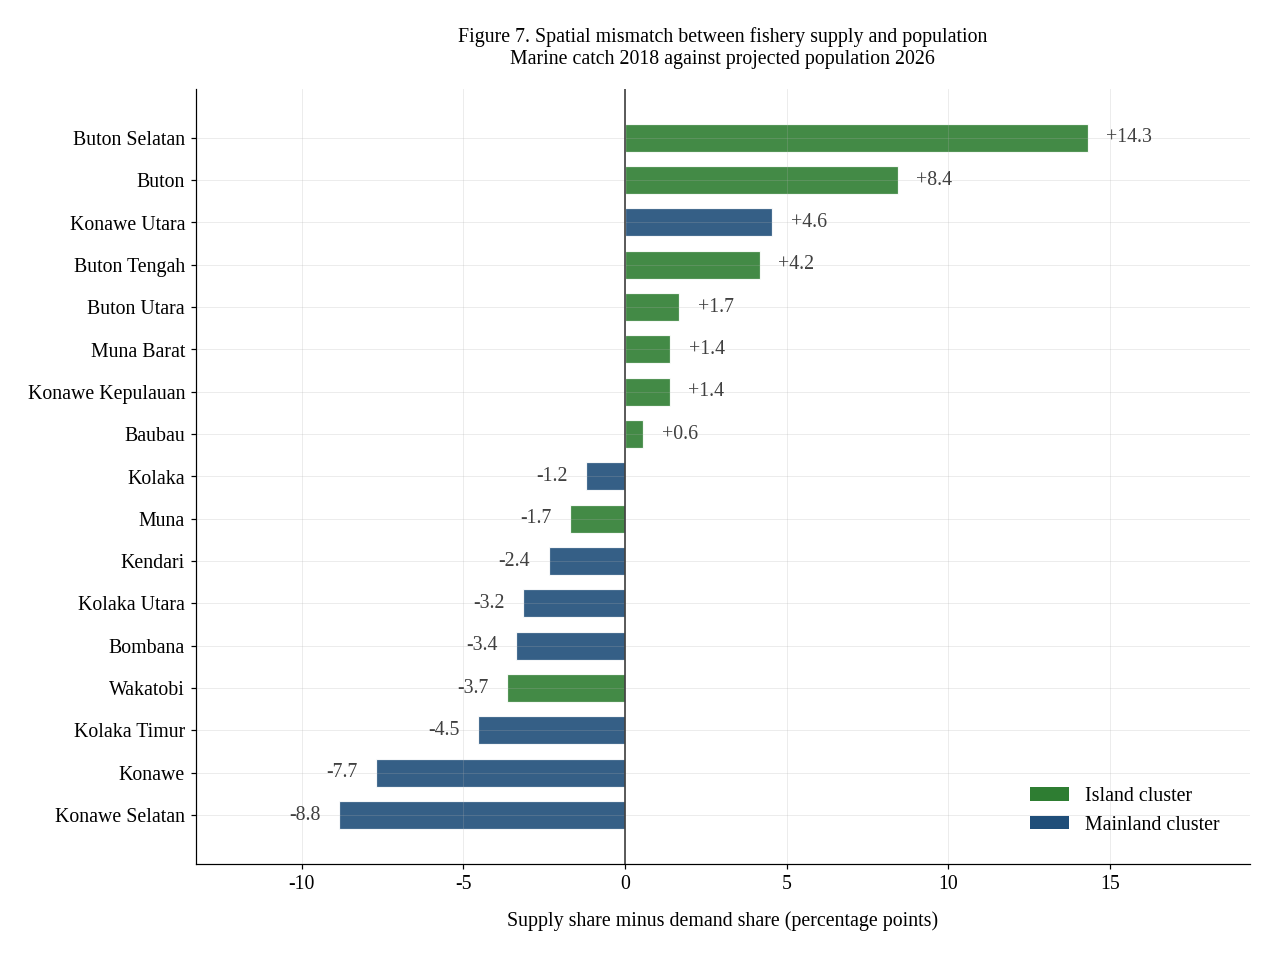

In [ ]:
urut_ruang = RUANG.sort_values("mismatch")
warna_ruang = [WARNA["aksen"] if g == "kepulauan" else WARNA["struktural"]
               for g in urut_ruang["cluster"]]

fig, sb = plt.subplots(figsize=(11.5, 8.6))
posisi = np.arange(len(urut_ruang))
sb.barh(posisi, urut_ruang["mismatch"] * 100, color=warna_ruang, alpha=0.9,
        height=0.66, edgecolor="white", linewidth=0.8)
sb.set_yticks(posisi)
sb.set_yticklabels(urut_ruang.index)
sb.axvline(0, color=WARNA["netral"], lw=1.1)
sb.set_xlabel("Supply share minus demand share (percentage points)", labelpad=11)
sb.set_title("Figure 7. Spatial mismatch between fishery supply and population\n"
             "Marine catch %d against projected population 2026" % tahun_ikan, pad=16)

jarak = urut_ruang["mismatch"].abs().max() * 100 * 0.04
for i, v in enumerate(urut_ruang["mismatch"] * 100):
    sb.text(v + (jarak if v >= 0 else -jarak), i, "%+.1f" % v, va="center",
            ha="left" if v >= 0 else "right", fontsize=13, color=WARNA["netral"])

sb.set_xlim(urut_ruang["mismatch"].min() * 100 * 1.5,
            urut_ruang["mismatch"].max() * 100 * 1.35)
penanda = [matplotlib.patches.Patch(facecolor=WARNA["aksen"], label="Island cluster"),
           matplotlib.patches.Patch(facecolor=WARNA["struktural"], label="Mainland cluster")]
sb.legend(handles=penanda, loc="lower right", borderaxespad=1.1)
plt.tight_layout()
fig.savefig(os.path.join(JALUR["04_gambar"], "figure7_spatial_mismatch.png"))
plt.show()

### Gambar kedelapan, hasil alokasi optimal menurut batas serapan

Grafik kiri menunjukkan berapa besar kebutuhan yang dapat dipenuhi dari dalam provinsi
pada berbagai batas serapan. Grafik kanan menunjukkan nilai yang tertahan di dalam
provinsi. Bentuk kurva menjelaskan sampai titik mana penambahan batas serapan masih
memberi tambahan manfaat.


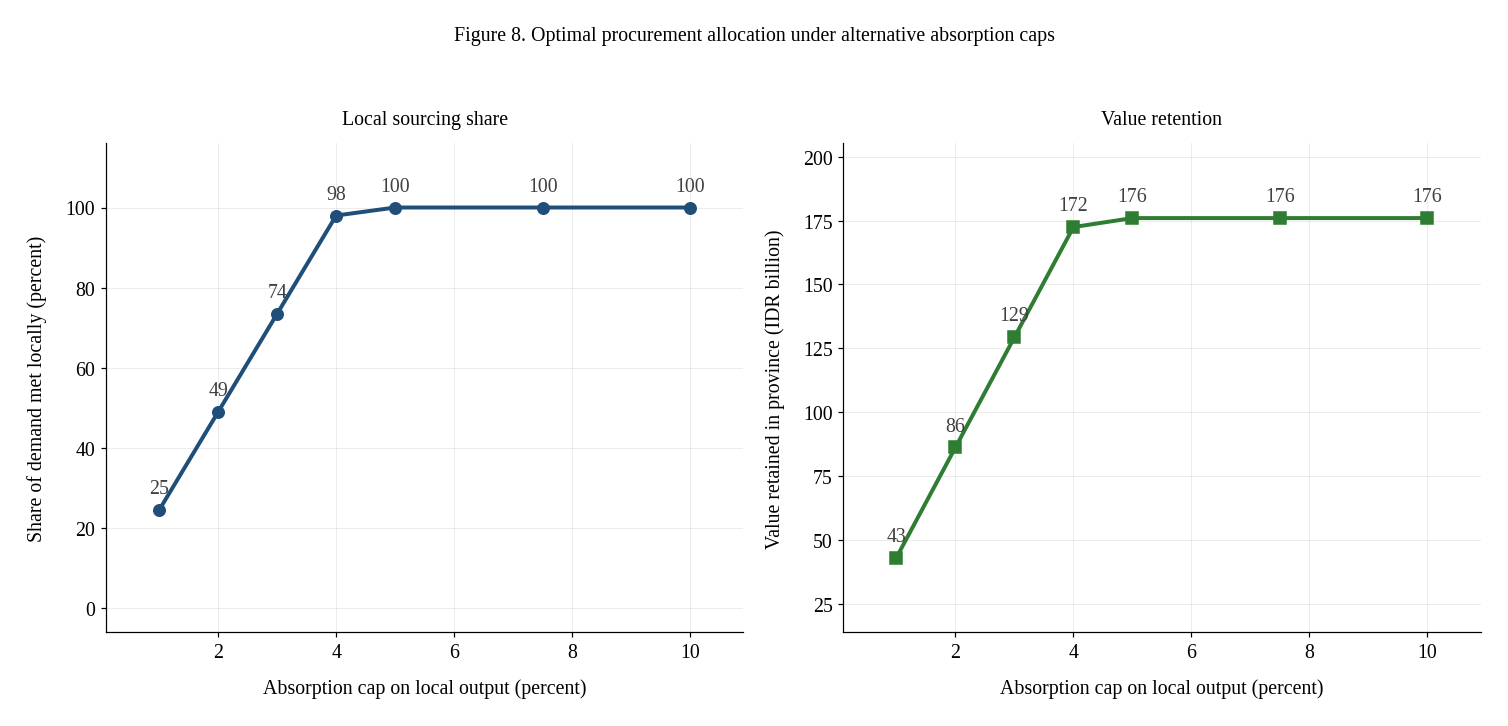

In [ ]:
fig, (kiri, kanan) = plt.subplots(1, 2, figsize=(13.6, 6.4))

kiri.plot(TABEL8["Absorption cap"] * 100, TABEL8["Local share"] * 100,
          marker="o", ms=7.5, lw=2.6, color=WARNA["struktural"])
kiri.set_xlabel("Absorption cap on local output (percent)", labelpad=11)
kiri.set_ylabel("Share of demand met locally (percent)", labelpad=12)
kiri.set_title("Local sourcing share", pad=13)
kiri.set_ylim(-6, 116)
kiri.margins(x=0.10)
for x, y in zip(TABEL8["Absorption cap"] * 100, TABEL8["Local share"] * 100):
    kiri.annotate("%.0f" % y, xy=(x, y), xytext=(0, 11),
                  textcoords="offset points", ha="center", fontsize=13,
                  color=WARNA["netral"])

kanan.plot(TABEL8["Absorption cap"] * 100, TABEL8["Value retained (IDR)"] / 1e9,
           marker="s", ms=7.5, lw=2.6, color=WARNA["aksen"])
kanan.set_xlabel("Absorption cap on local output (percent)", labelpad=11)
kanan.set_ylabel("Value retained in province (IDR billion)", labelpad=12)
kanan.set_title("Value retention", pad=13)
kanan.margins(y=0.22, x=0.10)
for x, y in zip(TABEL8["Absorption cap"] * 100, TABEL8["Value retained (IDR)"] / 1e9):
    kanan.annotate("%.0f" % y, xy=(x, y), xytext=(0, 11),
                   textcoords="offset points", ha="center", fontsize=13,
                   color=WARNA["netral"])

fig.suptitle("Figure 8. Optimal procurement allocation under alternative absorption caps",
             y=0.985)
plt.tight_layout(rect=[0, 0, 1, 0.955])
fig.savefig(os.path.join(JALUR["04_gambar"], "figure8_allocation_scenarios.png"))
plt.show()

## Langkah 8. Interpretasi otomatis

Interpretasi disusun oleh fungsi yang membaca langsung tabel hasil, bukan oleh teks yang
diketik lebih dahulu. Setiap kalimat hanya boleh memuat angka yang benar benar dihitung
pada langkah sebelumnya, dan setiap pernyataan kualitatif ditentukan oleh aturan ambang
yang tertulis di dalam kode.

Aturan ini membuat interpretasi berubah dengan sendirinya apabila data diperbarui, dan
membuat kesimpulan yang tidak didukung angka tidak mungkin muncul. Jika sebuah pengujian
tidak menghasilkan bukti yang cukup, fungsi akan menyatakan hal itu secara terbuka alih
alih memaksakan simpulan.


In [ ]:
def rp(x, desimal=0):
    return "Rp" + format(round(float(x), desimal), "," if desimal == 0 else ",.%df" % desimal)

def interpretasi_lapis1():
    t = TABEL1
    struktural = t[t["Classification"] == "Structural friction"]
    koordinasi = t[t["Classification"] == "Coordination failure"]
    baris = []
    baris.append("LAPIS PERTAMA. DIAGNOSIS FRIKSI PASAR")
    baris.append("")
    baris.append("Sepuluh komoditas pangan strategis diuji dengan %d pengamatan bulanan."
                 % int(t["Obs."].iloc[0]))
    baris.append("Sebanyak %d komoditas digolongkan sebagai friksi struktural, %d komoditas "
                 "sebagai kegagalan koordinasi, dan %d komoditas berada di antara keduanya."
                 % (len(struktural), len(koordinasi),
                    len(t) - len(struktural) - len(koordinasi)))
    baris.append("")
    if len(struktural):
        nm = ", ".join(struktural.index)
        baris.append("Kelompok friksi struktural terdiri atas %s. Pada kelompok ini pangsa "
                     "ragam permanen berkisar %.2f sampai %.2f, yang berarti sebagian besar "
                     "selisih harga antarkota tidak hilang dengan berjalannya waktu."
                     % (nm, struktural["Permanent share"].min(),
                        struktural["Permanent share"].max()))
        tak_stasioner = struktural[struktural["ADF p-value"] > 0.05]
        if len(tak_stasioner):
            baris.append("Uji akar unit mendukung pembacaan tersebut. Pada %d dari %d "
                         "komoditas kelompok ini hipotesis akar unit tidak dapat ditolak "
                         "pada taraf lima persen, sehingga selisih harga tidak kembali ke "
                         "satu nilai tetap."
                         % (len(tak_stasioner), len(struktural)))
        else:
            baris.append("Uji akar unit tidak sepenuhnya sejalan dengan penggolongan ini, "
                         "sehingga kesimpulan pada kelompok ini perlu dibaca dengan hati "
                         "hati.")
    baris.append("")
    if len(koordinasi):
        nm = ", ".join(koordinasi.index)
        stasioner = koordinasi[koordinasi["ADF p-value"] < 0.05]
        baris.append("Kelompok kegagalan koordinasi terdiri atas %s. Pangsa ragam permanen "
                     "pada kelompok ini paling tinggi %.2f, sedangkan simpangan baku "
                     "komponen sementara mencapai %.1f poin persen."
                     % (nm, koordinasi["Permanent share"].max(),
                        koordinasi["SD transitory (pp)"].max()))
        baris.append("Sebanyak %d dari %d komoditas pada kelompok ini menolak hipotesis akar "
                     "unit pada taraf lima persen, yang berarti selisih harganya kembali ke "
                     "satu nilai tetap dan karena itu bukan berasal dari biaya angkut."
                     % (len(stasioner), len(koordinasi)))
    baris.append("")
    baris.append("Implikasi kebijakan berbeda untuk kedua kelompok. Kelompok pertama "
                 "menuntut perbaikan sarana dan jadwal angkutan. Kelompok kedua menuntut "
                 "penyebaran informasi harga dan pencocokan pembeli dengan penjual, karena "
                 "pelebaran jalan tidak akan mengurangi selisih yang sumbernya bukan jarak.")
    baris.append("")
    baris.append("Biaya friksi struktural rata rata pada kelompok logistik setara %.2f persen "
                 "dari harga eceran, atau sekitar %s per kilogram pada tingkat harga "
                 "rata rata contoh."
                 % (FRIKSI_RERATA_PCT,
                    rp(BIAYA_FRIKSI.loc[BIAYA_FRIKSI.permanent_share >= 0.5,
                                        "friction_cost_idr_kg"].mean())))
    return "\n".join(baris)

def interpretasi_lapis2():
    b = []
    b.append("LAPIS KEDUA. STRUKTUR PENJALARAN GUNCANGAN HARGA")
    b.append("")
    b.append("Sistem yang dianalisis memuat %d deret harga pada %d bulan pengamatan. "
             "Setelah penyusutan, hanya %.1f persen koefisien vektor autoregresi yang "
             "bernilai tidak nol, sehingga jaringan yang terbentuk bersifat renggang."
             % (PANEL_HARGA.shape[1], PANEL_HARGA.shape[0], KEPADATAN * 100))
    b.append("")
    b.append("Indeks konektivitas total mencapai %.2f persen. Angka ini berarti bahwa "
             "rata rata %.0f persen ragam galat ramalan sebuah harga ditentukan oleh "
             "guncangan pada harga lain, bukan oleh guncangan pada dirinya sendiri."
             % (TCI, TCI))
    if TCI >= 50:
        b.append("Nilai di atas lima puluh persen menunjukkan pasar pangan yang saling "
                 "terkait erat, sehingga guncangan pada satu komoditas sulit ditangani "
                 "secara terpisah.")
    else:
        b.append("Nilai di bawah lima puluh persen menunjukkan penjalaran yang terbatas, "
                 "sehingga penanganan per komoditas masih dapat dibenarkan.")
    b.append("")
    pemancar = KONEKTIVITAS.head(3)
    penerima = KONEKTIVITAS.tail(3)
    b.append("Tiga deret dengan konektivitas bersih tertinggi adalah %s. Ketiganya lebih "
             "banyak memancarkan guncangan daripada menerimanya, sehingga pemantauan "
             "harga sebaiknya diprioritaskan pada deret tersebut."
             % ", ".join("%s dengan nilai bersih %.1f" % (i.replace("Ken_", "Kendari ")
                         .replace("Bau_", "Baubau "), v)
                         for i, v in pemancar["Net"].items()))
    b.append("Tiga deret dengan konektivitas bersih terendah adalah %s. Ketiganya terutama "
             "menerima guncangan, sehingga tindakan yang hanya menyasar deret ini tidak "
             "akan banyak mengubah keadaan."
             % ", ".join("%s dengan nilai bersih %.1f" % (i.replace("Ken_", "Kendari ")
                         .replace("Bau_", "Baubau "), v)
                         for i, v in penerima["Net"].items()))
    b.append("")
    b.append("Pengujian dugaan kota pusat memberikan hasil berikut. Arus guncangan dari "
             "Kendari ke Baubau sebesar %.2f persen dari total, sedangkan arus sebaliknya "
             "sebesar %.2f persen, sehingga rasio dominasi Kendari adalah %.3f."
             % (ken_ke_bau / total_blok * 100, bau_ke_ken / total_blok * 100, RASIO_PUSAT))
    if 0.80 <= RASIO_PUSAT <= 1.25:
        b.append("Rasio yang mendekati satu berarti dugaan Kendari sebagai kota pusat "
                 "penyalur guncangan tidak didukung data. Kedua kota lebih tepat dibaca "
                 "sebagai penerima sejajar dari guncangan yang berasal dari luar provinsi.")
        b.append("Temuan ini memperkuat kesimpulan lapis pertama. Pasar pangan di dalam "
                 "provinsi belum terbentuk sebagai satu kesatuan yang saling memasok, "
                 "melainkan sebagai dua pasar yang sama sama bergantung pada pasokan luar.")
    elif RASIO_PUSAT > 1.25:
        b.append("Rasio di atas satu koma dua lima mendukung dugaan Kendari sebagai kota "
                 "pusat penyalur guncangan, sehingga pengendalian harga di Kendari akan "
                 "berdampak lebih luas.")
    else:
        b.append("Rasio di bawah nol koma delapan menunjukkan Baubau justru lebih banyak "
                 "menyalurkan guncangan daripada Kendari, yang berlawanan dengan dugaan "
                 "awal dan perlu ditelusuri lebih jauh.")
    b.append("")
    b.append("Limpahan di dalam kota sendiri masih lebih besar daripada limpahan antarkota, "
             "yaitu %.1f persen untuk Baubau dan %.1f persen untuk Kendari, dibandingkan "
             "%.1f persen dan %.1f persen untuk arus antarkota."
             % (dalam_bau / total_blok * 100, dalam_ken / total_blok * 100,
                ken_ke_bau / total_blok * 100, bau_ke_ken / total_blok * 100))
    return "\n".join(b)

def interpretasi_hilirisasi():
    b = []
    b.append("TANGGA NILAI PERIKANAN")
    b.append("")
    b.append("Pada tahun penuh terakhir yang tersedia, yaitu %d, nilai satuan ekspor ikan "
             "dalam bentuk mentah tercatat %s per kilogram, sedangkan nilai satuan ekspor "
             "olahan tercatat %s per kilogram."
             % (tahun_penuh, rp(baris["Raw fish unit value (IDR/kg)"]),
                rp(baris["Processed unit value (IDR/kg)"])))
    b.append("Selisih tersebut setara %.2f kali lipat. Harga yang diterima produsen pada "
             "tingkat pendaratan sebesar %s per kilogram, sehingga nilai satuan ekspor "
             "mentah setara %.1f kali harga produsen dan nilai satuan ekspor olahan setara "
             "%.1f kali harga produsen."
             % (PREMI_OLAHAN, rp(HARGA_PRODUSEN),
                baris["Raw fish unit value (IDR/kg)"] / HARGA_PRODUSEN,
                baris["Processed unit value (IDR/kg)"] / HARGA_PRODUSEN))
    b.append("")
    b.append("Volume ekspor olahan pada %d sebesar %s ton, atau %.1f persen dari volume "
             "ekspor mentah yang sebesar %s ton. Kemampuan mengolah sudah terbentuk namun "
             "besarannya masih kecil."
             % (tahun_penuh, format(baris["Processed volume (tonnes)"], ",.0f"),
                baris["Processed volume (tonnes)"] / baris["Raw fish volume (tonnes)"] * 100,
                format(baris["Raw fish volume (tonnes)"], ",.0f")))
    b.append("")
    b.append("Total nilai ekspor perikanan %d mencapai %.3f triliun rupiah pada kurs "
             "rata rata %s per dolar Amerika Serikat. Sebagai pembanding, anggaran bahan "
             "baku program Makan Bergizi Gratis di Sulawesi Tenggara diperkirakan %.3f "
             "sampai %.3f triliun rupiah setahun."
             % (tahun_penuh, NILAI_EKSPOR_IKAN_IDR / 1e12,
                rp(baris["Exchange rate (IDR/USD)"]),
                ANGGARAN_MIN / 1e12, ANGGARAN_MAK / 1e12))
    kelipatan = ANGGARAN_MIN / NILAI_EKSPOR_IKAN_IDR
    b.append("Perbandingan tersebut setara %.2f kali, yang berarti permintaan pangan yang "
             "dijamin program di dalam provinsi sudah sebanding dengan seluruh nilai "
             "ekspor perikanan ke luar negeri." % kelipatan)
    b.append("")
    b.append("Catatan pembatas. Pos tarif tiga memuat pula udang dan biota bernilai tinggi "
             "lain, sehingga perbandingan terhadap harga ikan tongkol menunjukkan arah "
             "besaran dan bukan kesetaraan jenis. Angka hari layanan sebanyak %d hari "
             "merupakan asumsi rancangan dan bukan ketetapan resmi." % int(HARI_LAYANAN))
    return "\n".join(b)

def interpretasi_lapis3():
    b = []
    b.append("LAPIS KETIGA. ALOKASI PERMINTAAN TERJAMIN")
    b.append("")
    b.append("Indeks ketidaksesuaian ruang bernilai %.4f. Angka ini berarti %.1f persen "
             "produksi perikanan harus berpindah kabupaten agar sebaran pasokan sama "
             "dengan sebaran kebutuhan."
             % (INDEKS_KETIDAKSESUAIAN, INDEKS_KETIDAKSESUAIAN * 100))
    surplus = RUANG.nlargest(3, "mismatch")
    defisit = RUANG.nsmallest(3, "mismatch")
    b.append("Tiga kabupaten dengan surplus terbesar adalah %s."
             % ", ".join("%s sebesar %+.1f poin persen" % (i, v * 100)
                         for i, v in surplus["mismatch"].items()))
    b.append("Tiga wilayah dengan defisit terbesar adalah %s."
             % ", ".join("%s sebesar %+.1f poin persen" % (i, v * 100)
                         for i, v in defisit["mismatch"].items()))
    b.append("")
    b.append("Kebutuhan ikan program setara %.2f persen produksi perikanan tangkap "
             "provinsi. Angka ini menegaskan bahwa kapasitas pasokan bukan kendala yang "
             "mengikat." % (RASIO_KEBUTUHAN * 100))
    b.append("")
    b.append("Hasil pemrograman linear pada skenario dasar dengan batas serapan %.0f "
             "persen menunjukkan bahwa %s ton atau %.1f persen kebutuhan ikan program "
             "dapat dipenuhi dari dalam provinsi, dengan nilai yang sampai ke produsen "
             "sebesar %.3f triliun rupiah."
             % (BATAS_DASAR * 100, format(DASAR["ton_lokal"], ",.0f"),
                DASAR["pangsa_lokal"] * 100, DASAR["nilai_tertahan"] / 1e12))
    b.append("Anggaran yang dialokasikan untuk ikan diperkirakan %.3f triliun rupiah, "
             "sehingga marjin rantai pasok mencapai %.3f triliun rupiah atau %.1f persen. "
             "Marjin inilah ruang perbaikan yang tersedia tanpa menambah anggaran."
             % (ANGGARAN_IKAN_MIN / 1e12, MARJIN_RANTAI / 1e12, PANGSA_MARJIN * 100))
    penuh = TABEL8[TABEL8["Local share"] >= 0.999]
    if len(penuh):
        phi_min = penuh["Absorption cap"].min()
        b.append("Seluruh kebutuhan dapat dipenuhi dari dalam provinsi mulai batas serapan "
                 "%.0f persen. Di atas batas tersebut penambahan kapasitas serapan tidak "
                 "lagi menambah retensi nilai, sehingga upaya sebaiknya dialihkan pada "
                 "perbaikan mutu dan keandalan pasokan." % (phi_min * 100))
    else:
        b.append("Pada seluruh skenario yang diuji, kebutuhan belum dapat dipenuhi "
                 "sepenuhnya dari dalam provinsi, sehingga peningkatan kapasitas pasokan "
                 "tetap diperlukan.")
    b.append("")
    b.append("Tarif friksi yang dipakai dalam optimisasi sebesar %s per kilogram, yang "
             "diturunkan dari lapis pertama dan bukan dari asumsi bebas. Pengiriman "
             "antargugus geografis dikenai %.1f kali tarif tersebut, dan pendatangan dari "
             "luar provinsi dikenai %.1f kali tarif tersebut ditambah selisih harga "
             "sebesar %.0f persen."
             % (rp(TARIF_FRIKSI), LIPAT_ANTARGUGUS, LIPAT_LUAR, PREMI_LUAR * 100))
    b.append("")
    b.append("Catatan pembatas. Matriks jarak antarkabupaten tidak tersedia sehingga biaya "
             "perpindahan disusun bertingkat menurut gugus geografis. Pangsa ikan dalam "
             "nilai bahan baku sebesar %.0f persen dan berat ikan per porsi sebesar %.0f "
             "gram merupakan asumsi rancangan yang perlu dikonfirmasi kepada Badan Gizi "
             "Nasional." % (PANGSA_IKAN * 100, GRAM_IKAN * 1000))
    return "\n".join(b)

def interpretasi_gabungan():
    b = ["RINGKASAN LINTAS LAPIS", ""]
    b.append("Ketiga lapis analisis mengarah pada satu simpulan yang sama. Persoalan pangan "
             "di Sulawesi Tenggara bukan terutama persoalan jumlah produksi, melainkan "
             "persoalan pencocokan antara produksi yang tersebar dan permintaan yang sudah "
             "tersedia.")
    b.append("")
    b.append("Lapis pertama menunjukkan bahwa selisih harga antarkota pada komoditas yang "
             "diproduksi setempat tidak bersifat menetap, sehingga sumbernya bukan biaya "
             "angkut melainkan ketiadaan informasi dan koordinasi.")
    b.append("Lapis kedua menunjukkan bahwa kedua kota yang diamati tidak membentuk "
             "hubungan pusat dan pinggiran, melainkan sama sama menerima guncangan dari "
             "luar, yang berarti pasar pangan di dalam provinsi belum menyatu.")
    b.append("Tangga nilai perikanan menunjukkan bahwa nilai yang keluar dalam bentuk "
             "bahan mentah setara dengan besaran permintaan yang sebenarnya sudah ada di "
             "dalam provinsi melalui program pemberian makan bergizi.")
    b.append("Lapis ketiga menunjukkan bahwa dengan batas serapan yang wajar, sebagian "
             "besar kebutuhan tersebut dapat dipenuhi dari dalam provinsi, dan bahwa "
             "hambatan utamanya adalah penjadwalan serta kepastian pasokan, bukan "
             "ketersediaan bahan.")
    return "\n".join(b)

BAGIAN = [interpretasi_lapis1(), interpretasi_lapis2(),
          interpretasi_hilirisasi(), interpretasi_lapis3(),
          interpretasi_gabungan()]
INTERPRETASI = ("\n\n" + "=" * 78 + "\n\n").join(BAGIAN)
print(INTERPRETASI)

with open(os.path.join(JALUR["05_interpretasi"], "interpretasi_otomatis.txt"),
          "w", encoding="utf-8") as f:
    f.write(INTERPRETASI)

LAPIS PERTAMA. DIAGNOSIS FRIKSI PASAR

Sepuluh komoditas pangan strategis diuji dengan 72 pengamatan bulanan.
Sebanyak 4 komoditas digolongkan sebagai friksi struktural, 5 komoditas sebagai kegagalan koordinasi, dan 1 komoditas berada di antara keduanya.

Kelompok friksi struktural terdiri atas Gula Pasir, Beras, Daging Sapi, Minyak Goreng. Pada kelompok ini pangsa ragam permanen berkisar 0.52 sampai 1.00, yang berarti sebagian besar selisih harga antarkota tidak hilang dengan berjalannya waktu.
Uji akar unit mendukung pembacaan tersebut. Pada 4 dari 4 komoditas kelompok ini hipotesis akar unit tidak dapat ditolak pada taraf lima persen, sehingga selisih harga tidak kembali ke satu nilai tetap.

Kelompok kegagalan koordinasi terdiri atas Cabai Rawit, Telur Ayam, Daging Ayam, Cabai Merah, Bawang Merah. Pangsa ragam permanen pada kelompok ini paling tinggi 0.17, sedangkan simpangan baku komponen sementara mencapai 24.2 poin persen.
Sebanyak 5 dari 5 komoditas pada kelompok ini menolak hi

## Langkah 9. Daftar pustaka terverifikasi

Setiap rujukan di bawah ini telah diperiksa keberadaannya beserta nomor jilid, nomor
terbitan, dan halamannya. Tautan yang dicantumkan mengarah pada berkas atau halaman resmi
yang dapat dibuka. Rujukan yang naskahnya tersedia bebas ditandai pada keterangan agar
mudah ditelusuri kembali oleh pembaca dan dewan juri.

Sumber data primer dicantumkan terpisah dari rujukan metode, karena keduanya memiliki
kedudukan yang berbeda dalam menilai keandalan hasil.


In [ ]:
PUSTAKA_METODE = [
 dict(sitasi="Demirer, M., Diebold, F. X., Liu, L., & Yilmaz, K. (2018). Estimating global "
             "bank network connectedness. Journal of Applied Econometrics, 33(1), 1-15.",
      doi="https://doi.org/10.1002/jae.2585",
      akses="Naskah penulis tersedia bebas di "
            "https://www.sas.upenn.edu/~fdiebold/papers2/DDLYpaper.pdf",
      pakai="Pendugaan vektor autoregresi berdimensi tinggi dengan penyusutan"),
 dict(sitasi="Diebold, F. X., & Yilmaz, K. (2012). Better to give than to receive: "
             "Predictive directional measurement of volatility spillovers. International "
             "Journal of Forecasting, 28(1), 57-66.",
      doi="https://doi.org/10.1016/j.ijforecast.2011.02.006",
      akses="Versi kertas kerja tersedia bebas di https://ideas.repec.org/p/koc/wpaper/1001.html",
      pakai="Ukuran konektivitas total, terarah, dan bersih"),
 dict(sitasi="Diebold, F. X., & Yilmaz, K. (2014). On the network topology of variance "
             "decompositions: Measuring the connectedness of financial firms. Journal of "
             "Econometrics, 182(1), 119-134.",
      doi="https://doi.org/10.1016/j.jeconom.2014.04.012",
      akses="Terindeks di https://econpapers.repec.org/RePEc:eee:econom:v:182:y:2014:i:1:p:119-134",
      pakai="Penafsiran matriks dekomposisi varians sebagai jaringan berarah"),
 dict(sitasi="Durbin, J., & Koopman, S. J. (2012). Time series analysis by state space "
             "methods (2nd ed.). Oxford University Press.",
      doi="https://doi.org/10.1093/acprof:oso/9780199641178.001.0001",
      akses="Buku, tidak tersedia bebas",
      pakai="Saringan Kalman dan pendugaan kemungkinan maksimum model ruang keadaan"),
 dict(sitasi="Hansen, B. E. (1999). Threshold effects in non-dynamic panels: Estimation, "
             "testing, and inference. Journal of Econometrics, 93(2), 345-368.",
      doi="https://doi.org/10.1016/S0304-4076(99)00025-1",
      akses="Naskah penulis tersedia bebas di "
            "https://users.ssc.wisc.edu/~bhansen/papers/joe_99.html",
      pakai="Rujukan pendugaan ambang dan pengujian dengan penarikan ulang contoh"),
 dict(sitasi="Harvey, A. C. (1989). Forecasting, structural time series models and the "
             "Kalman filter. Cambridge University Press.",
      doi="https://doi.org/10.1017/CBO9781107049994",
      akses="Buku, tidak tersedia bebas",
      pakai="Model taraf lokal dan penguraian komponen permanen serta sementara"),
 dict(sitasi="Koop, G., Pesaran, M. H., & Potter, S. M. (1996). Impulse response analysis "
             "in nonlinear multivariate models. Journal of Econometrics, 74(1), 119-147.",
      doi="https://doi.org/10.1016/0304-4076(95)01753-4",
      akses="Terindeks di https://econpapers.repec.org/RePEc:eee:econom:v:74:y:1996:i:1:p:119-147",
      pakai="Landasan bentuk tergeneralisasi yang tidak bergantung urutan peubah"),
 dict(sitasi="Kwiatkowski, D., Phillips, P. C. B., Schmidt, P., & Shin, Y. (1992). Testing "
             "the null hypothesis of stationarity against the alternative of a unit root. "
             "Journal of Econometrics, 54(1-3), 159-178.",
      doi="https://doi.org/10.1016/0304-4076(92)90104-Y",
      akses="Terindeks di https://econpapers.repec.org/RePEc:eee:econom:v:54:y:1992:i:1-3:p:159-178",
      pakai="Uji kestasioneran sebagai pemeriksaan silang uji akar unit"),
 dict(sitasi="Pesaran, H. H., & Shin, Y. (1998). Generalized impulse response analysis in "
             "linear multivariate models. Economics Letters, 58(1), 17-29.",
      doi="https://doi.org/10.1016/S0165-1765(97)00214-0",
      akses="Terindeks di https://econpapers.repec.org/RePEc:eee:ecolet:v:58:y:1998:i:1:p:17-29",
      pakai="Dekomposisi varians galat ramalan yang tidak bergantung urutan peubah"),
 dict(sitasi="Said, S. E., & Dickey, D. A. (1984). Testing for unit roots in "
             "autoregressive-moving average models of unknown order. Biometrika, 71(3), "
             "599-607.",
      doi="https://doi.org/10.1093/biomet/71.3.599",
      akses="Terindeks di https://academic.oup.com/biomet/article/71/3/599/262034",
      pakai="Uji akar unit Dickey dan Fuller yang diperluas"),
 dict(sitasi="Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. "
             "Journal of the Royal Statistical Society Series B, 58(1), 267-288.",
      doi="https://doi.org/10.1111/j.2517-6161.1996.tb02080.x",
      akses="Terindeks di https://www.jstor.org/stable/2346178",
      pakai="Penyusutan koefisien pada sistem berdimensi tinggi"),
]

PUSTAKA_DATA = [
 dict(sitasi="Badan Pusat Statistik Provinsi Sulawesi Tenggara. Indeks harga konsumen dan "
             "inflasi menurut kelompok pengeluaran, Kota Kendari, Kota Baubau, Kabupaten "
             "Konawe, dan Kabupaten Kolaka, tahun dasar 2022 sama dengan 100.",
      akses="https://sultra.bps.go.id",
      pakai="Panel indeks harga konsumen empat wilayah, Januari 2024 sampai Juli 2026"),
 dict(sitasi="Badan Pusat Statistik. Nilai dan volume ekspor serta impor menurut provinsi "
             "dan kode Harmonized System dua digit, kode provinsi 74.",
      akses="https://www.bps.go.id",
      pakai="Tangga nilai perikanan dan kurs rata rata bulanan"),
 dict(sitasi="Badan Pusat Statistik Provinsi Sulawesi Tenggara. Nilai tukar petani menurut "
             "subsektor, bulanan.",
      akses="https://sultra.bps.go.id",
      pakai="Perbandingan indeks harga diterima dan dibayar produsen"),
 dict(sitasi="Badan Pusat Statistik Provinsi Sulawesi Tenggara. Proyeksi penduduk menurut "
             "kabupaten dan kota hasil Sensus Penduduk 2020.",
      akses="https://sultra.bps.go.id",
      pakai="Sebaran kebutuhan menurut kabupaten pada lapis ketiga"),
 dict(sitasi="Dinas Kelautan dan Perikanan Provinsi Sulawesi Tenggara. Data rumah tangga "
             "perikanan dan produksi perikanan tangkap di perairan laut menurut kabupaten "
             "dan kota.",
      akses="Publikasi dinas, dikutip melalui berkas Data Produksi",
      pakai="Kapasitas pasokan menurut kabupaten pada lapis ketiga"),
 dict(sitasi="Bank Indonesia. Pusat Informasi Harga Pangan Strategis.",
      akses="https://www.bi.go.id",
      pakai="Harga eceran bulanan sepuluh komoditas pangan di Kendari dan Baubau"),
 dict(sitasi="Badan Pangan Nasional. Panel harga pangan.",
      akses="https://panelharga.badanpangan.go.id",
      pakai="Harga produsen ikan tongkol tingkat provinsi"),
]

def susun_pustaka():
    b = ["DAFTAR PUSTAKA", "", "A. RUJUKAN METODE", ""]
    for i, p in enumerate(sorted(PUSTAKA_METODE, key=lambda d: d["sitasi"]), 1):
        b += ["%d. %s" % (i, p["sitasi"]),
              "   Pengenal objek digital: %s" % p["doi"],
              "   Ketersediaan: %s" % p["akses"],
              "   Dipakai untuk: %s" % p["pakai"], ""]
    b += ["", "B. SUMBER DATA PRIMER", ""]
    for i, p in enumerate(PUSTAKA_DATA, 1):
        b += ["%d. %s" % (i, p["sitasi"]),
              "   Ketersediaan: %s" % p["akses"],
              "   Dipakai untuk: %s" % p["pakai"], ""]
    b += ["", "C. CATATAN PENGGUNAAN",
          "",
          "Seluruh rujukan metode telah diperiksa nomor jilid, nomor terbitan, dan",
          "halamannya. Rujukan yang naskahnya tersedia bebas ditandai pada keterangan",
          "ketersediaan. Sumber data primer dicantumkan menurut lembaga penerbit karena",
          "berkas yang dipakai merupakan tabel dinamis yang alamatnya dapat berubah.",
          "",
          "Kurs yang dipakai untuk konversi nilai ekspor diambil dari baris kurs pada",
          "berkas nilai ekspor yang sama, sehingga nilai dan kurs berasal dari satu",
          "proses pengolahan dan tidak dapat menjadi tidak sinkron."]
    return "\n".join(b)

DAFTAR_PUSTAKA = susun_pustaka()
print(DAFTAR_PUSTAKA)

with open(os.path.join(JALUR["06_pustaka"], "daftar_pustaka.txt"), "w",
          encoding="utf-8") as f:
    f.write(DAFTAR_PUSTAKA)

pd.DataFrame(PUSTAKA_METODE).to_csv(
    os.path.join(JALUR["06_pustaka"], "pustaka_metode.csv"), index=False)
pd.DataFrame(PUSTAKA_DATA).to_csv(
    os.path.join(JALUR["06_pustaka"], "pustaka_data.csv"), index=False)

DAFTAR PUSTAKA

A. RUJUKAN METODE

1. Demirer, M., Diebold, F. X., Liu, L., & Yilmaz, K. (2018). Estimating global bank network connectedness. Journal of Applied Econometrics, 33(1), 1-15.
   Pengenal objek digital: https://doi.org/10.1002/jae.2585
   Ketersediaan: Naskah penulis tersedia bebas di https://www.sas.upenn.edu/~fdiebold/papers2/DDLYpaper.pdf
   Dipakai untuk: Pendugaan vektor autoregresi berdimensi tinggi dengan penyusutan

2. Diebold, F. X., & Yilmaz, K. (2012). Better to give than to receive: Predictive directional measurement of volatility spillovers. International Journal of Forecasting, 28(1), 57-66.
   Pengenal objek digital: https://doi.org/10.1016/j.ijforecast.2011.02.006
   Ketersediaan: Versi kertas kerja tersedia bebas di https://ideas.repec.org/p/koc/wpaper/1001.html
   Dipakai untuk: Ukuran konektivitas total, terarah, dan bersih

3. Diebold, F. X., & Yilmaz, K. (2014). On the network topology of variance decompositions: Measuring the connectedness of financia

## Langkah 10. Menyimpan seluruh keluaran dan mengunduh arsip

Sel terakhir menyusun catatan teknis yang merekam parameter, asumsi, dan versi pustaka
yang dipakai, lalu memampatkan seluruh folder keluaran menjadi satu berkas arsip dan
mengunduhnya secara otomatis.

Catatan teknis penting karena hasil analisis bergantung pada beberapa asumsi rancangan.
Merekamnya bersama hasil membuat perhitungan dapat ditelusuri ulang oleh pihak lain,
termasuk oleh penulis sendiri beberapa bulan kemudian.


In [ ]:
import sklearn, statsmodels, scipy

CATATAN = {
    "waktu_pengolahan": dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "versi_pustaka": {
        "numpy": np.__version__, "pandas": pd.__version__,
        "scipy": scipy.__version__, "statsmodels": statsmodels.__version__,
        "scikit_learn": sklearn.__version__, "matplotlib": matplotlib.__version__,
    },
    "huruf_visualisasi": FONT,
    "ukuran_huruf": 13,
    "parameter_terverifikasi": {
        "penerima_manfaat_mbg": PENERIMA_MBG,
        "jumlah_sppg": JUMLAH_SPPG,
        "mitra_pemasok": MITRA_PEMASOK,
        "bahan_baku_min_rp_porsi": BAHAN_BAKU_MIN,
        "bahan_baku_maks_rp_porsi": BAHAN_BAKU_MAK,
    },
    "asumsi_rancangan": {
        "hari_layanan_setahun": HARI_LAYANAN,
        "pangsa_ikan_dalam_bahan_baku": PANGSA_IKAN,
        "berat_ikan_per_porsi_kg": GRAM_IKAN,
        "premi_harga_luar_provinsi": PREMI_LUAR,
        "pengali_biaya_antargugus": LIPAT_ANTARGUGUS,
        "pengali_biaya_luar_provinsi": LIPAT_LUAR,
        "catatan": "Asumsi ini bukan angka resmi dan perlu dikonfirmasi kepada "
                   "Badan Gizi Nasional sebelum dipakai dalam naskah akhir.",
    },
    "hasil_utama": {
        "indeks_konektivitas_total_persen": round(float(TCI), 2),
        "rasio_dominasi_kendari": round(float(RASIO_PUSAT), 3),
        "indeks_ketidaksesuaian_ruang": round(float(INDEKS_KETIDAKSESUAIAN), 4),
        "biaya_friksi_struktural_persen": round(float(FRIKSI_RERATA_PCT), 2),
        "premi_pengolahan_kali": round(float(PREMI_OLAHAN), 2),
        "pangsa_lokal_skenario_dasar": round(float(DASAR["pangsa_lokal"]), 4),
        "nilai_tertahan_rp": round(float(DASAR["nilai_tertahan"]), 0),
        "kebutuhan_terhadap_produksi_persen": round(float(RASIO_KEBUTUHAN * 100), 2),
        "marjin_rantai_pasok_persen": round(float(PANGSA_MARJIN * 100), 1),
    },
    "batasan": [
        "Pos tarif tiga memuat udang dan biota bernilai tinggi lain sehingga "
        "perbandingan dengan harga ikan tongkol bersifat menunjukkan arah.",
        "Data produksi perikanan menurut kabupaten hanya lengkap pada tahun %d "
        "sehingga dipakai sebagai pola sebaran, bukan sebagai tingkat terkini."
        % tahun_ikan,
        "Panel indeks harga konsumen untuk Konawe dan Kolaka baru tersedia sejak "
        "Januari 2024 sehingga analisis konektivitas dibatasi pada dua kota.",
        "Matriks jarak antarkabupaten tidak tersedia sehingga biaya perpindahan "
        "disusun bertingkat menurut gugus geografis.",
    ],
}

with open(os.path.join(JALUR["05_interpretasi"], "catatan_teknis.json"), "w",
          encoding="utf-8") as f:
    json.dump(CATATAN, f, indent=2, ensure_ascii=False)

LAPORAN_MUTU.to_csv(os.path.join(JALUR["02_data_bersih"], "laporan_mutu_data.csv"),
                    index=False)

print("Catatan teknis tersimpan.")
print(json.dumps(CATATAN["hasil_utama"], indent=2, ensure_ascii=False))

Catatan teknis tersimpan.
{
  "indeks_konektivitas_total_persen": 54.6,
  "rasio_dominasi_kendari": 1.048,
  "indeks_ketidaksesuaian_ruang": 0.365,
  "biaya_friksi_struktural_persen": 5.3,
  "premi_pengolahan_kali": 3.68,
  "pangsa_lokal_skenario_dasar": 1.0,
  "nilai_tertahan_rp": 175956975047.0,
  "kebutuhan_terhadap_produksi_persen": 4.08,
  "marjin_rantai_pasok_persen": 47.3
}


In [ ]:
NAMA_ARSIP = "SIMPUL_Forkestra2026_hasil_%s" % dt.datetime.now().strftime("%Y%m%d_%H%M")
jalur_arsip = os.path.join(os.getcwd() if not DI_COLAB else "/content",
                           NAMA_ARSIP + ".zip")

jumlah = 0
with zipfile.ZipFile(jalur_arsip, "w", zipfile.ZIP_DEFLATED) as z:
    for akar, _, berkas in os.walk(JALUR["akar"]):
        if "01_data_mentah" in akar:      # data mentah tidak ikut agar arsip ringkas
            continue
        for nama in berkas:
            # Arsip dari eksekusi sebelumnya dilewati. Tanpa penyaringan ini setiap
            # eksekusi akan membungkus arsip lama ke dalam arsip baru dan ukurannya
            # berlipat terus menerus.
            if nama.lower().endswith(".zip"):
                continue
            penuh = os.path.join(akar, nama)
            z.write(penuh, os.path.relpath(penuh, JALUR["akar"]))
            jumlah += 1

ukuran = os.path.getsize(jalur_arsip) / 1e6
print("Arsip selesai dibuat.")
print("  Nama    :", os.path.basename(jalur_arsip))
print("  Isi     : %d berkas" % jumlah)
print("  Ukuran  : %.2f megabita" % ukuran)

# salinan arsip disimpan juga di Drive agar tidak hilang bila sesi berakhir
salinan = os.path.join(JALUR["akar"], os.path.basename(jalur_arsip))
if os.path.abspath(salinan) != os.path.abspath(jalur_arsip):
    shutil.copy2(jalur_arsip, salinan)
    print("  Salinan :", salinan)

if DI_COLAB:
    from google.colab import files
    files.download(jalur_arsip)
    print("\nUnduhan dimulai secara otomatis.")
else:
    print("\nDi luar Colab, arsip tersedia pada:", jalur_arsip)

Arsip selesai dibuat.
  Nama    : SIMPUL_Forkestra2026_hasil_20260821_1623.zip
  Isi     : 32 berkas
  Ukuran  : 2.51 megabita
  Salinan : /content/drive/MyDrive/SIMPUL_Forkestra2026/SIMPUL_Forkestra2026_hasil_20260821_1623.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Unduhan dimulai secara otomatis.
